# Exploratory Data Analysis and Advanced Classification of SSVEP EEG Signals — v5

**Author:** Kacper Szmigielski  
**Project context:** SSVEP-based control system for drone/object navigation  
**Dataset:** MAMEM3 via MOABB  
**Main methods:** Welch PSD, local SNR, CCA, FBCCA, frequency selection analysis

## Notebook objective

This notebook investigates whether SSVEP-related information can be extracted from EEG data and used for frequency classification. The analysis follows a step-by-step workflow:

1. inspect the dataset and selected EEG channels,
2. analyze the signal in the frequency domain using Welch PSD,
3. build a simple local-SNR baseline classifier,
4. evaluate standard CCA,
5. evaluate FBCCA,
6. check whether removing weak stimulation frequencies improves classification,
7. discuss practical implications for a future BCI control system.




# 1. Introduction

## 1.1 What is SSVEP?

A **Steady-State Visual Evoked Potential (SSVEP)** is an EEG response elicited by a visual stimulus flickering at a constant frequency. When a person focuses on a flickering visual target, the EEG signal, especially over posterior/occipital brain regions, may contain increased spectral power at the stimulation frequency and its harmonics.

In an SSVEP-based BCI system, each visual target can flicker at a different frequency. The user's intended command can then be inferred by identifying which stimulation frequency is most strongly represented in the EEG signal.

## 1.2 Project motivation

The long-term project motivation is a simple BCI control system where several flickering LEDs or visual fields correspond to control commands, for example:

- up,
- down,
- left,
- right,
- stop / hover / neutral.

Before building a real-time system, this notebook checks whether the candidate stimulation frequencies are separable in a public SSVEP dataset.

## 1.3 Research questions

This notebook investigates the following questions:

1. Are frequency-specific SSVEP components visible in the EEG spectrum?
2. Which stimulation frequencies are most separable?
3. How well does a simple local-SNR classifier perform?
4. Does CCA improve classification compared to local SNR?
5. Does FBCCA improve classification compared to standard CCA?
6. Should all available frequencies be used as control commands?

# 2. Dataset description

## 2.1 Dataset selection

The MAMEM3 dataset was selected because it is a public SSVEP dataset available through MOABB and contains a small number of stimulation frequencies. This makes it suitable for an exploratory analysis of a future control system based on a limited number of visual commands.

## 2.2 MAMEM3 details

According to the MOABB documentation, MAMEM3 is an SSVEP dataset with 11 subjects, 14 EEG channels, 128 Hz sampling frequency, 5 classes and 5-second trials. The five target frequencies are:

```text
6.66 Hz, 7.50 Hz, 8.57 Hz, 10.00 Hz, 12.00 Hz
```

The exact shape of the loaded epochs is verified programmatically below, because the final epoch length may depend on the MOABB paradigm configuration.

## 2.3 Dataset limitations

This analysis is offline and dataset-based. Therefore, the obtained classification accuracy should not be interpreted as direct proof that a real-time drone control system would work reliably. A practical online system would require:

- hardware validation with the actual LEDs or visual display,
- subject-specific calibration,
- online testing,
- artifact handling,
- confidence thresholds and safety mechanisms.

# 3. Environment and configuration

## 3.1 Libraries

In [2]:
import warnings
warnings.simplefilter("default")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.signal import welch, cheby1, butter, sosfiltfilt
from scipy.linalg import eigh
from sklearn.cross_decomposition import CCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from moabb.datasets import MAMEM3
from moabb.paradigms import SSVEP

/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/moabb/analysis/plotting.py:110: PendingDeprecationWarning: The set_under function will be deprecated in a future version. Use cmap.with_extremes(under=...) or Colormap(under=...) instead.
  _MOABB_SIGNIFICANCE_CMAP.set_under(color=[1, 1, 1])
/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/moabb/analysis/plotting.py:111: PendingDeprecationWarning: The set_over function will be deprecated in a future version. Use cmap.with_extremes(over=...) or Colormap(over=...) instead.
  _MOABB_SIGNIFICANCE_CMAP.set_over(color=MOABB_CORAL)
/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/moabb/pipelines/classification.py:8: DeprecationWarning: pyriemann.ut

## 3.2 Global constants

The channel names below correspond to the 14-channel Emotiv-style layout used in the loaded MAMEM3 representation.

In [3]:
FS = 128

TARGET_FREQS_ALL = [6.66, 7.50, 8.57, 10.00, 12.00]

EPOC_CHANNELS = [
    "AF3", "F7", "F3", "FC5", "T7", "P7", "O1",
    "O2", "P8", "T8", "FC6", "F4", "F8", "AF4",
]

POSTERIOR_CHANNELS = ["O1", "O2", "P7", "P8"]

POSTERIOR_CHANNEL_INDICES = [
    EPOC_CHANNELS.index(channel)
    for channel in POSTERIOR_CHANNELS
]

RANDOM_STATE = 42

## 3.3 Analysis configuration

Use this cell to quickly switch between the full 5-class setup and reduced frequency subsets.

In [4]:
# Default: full 5-class MAMEM3 problem.
SELECTED_TARGET_FREQS = TARGET_FREQS_ALL.copy()

# Exploratory 4-class subset excluding 6.66 Hz.
# This subset was motivated by results observed in the current dataset.
# SELECTED_TARGET_FREQS = [7.50, 8.57, 10.00, 12.00]

# Exploratory 3-class subset.
# Its performance should not be interpreted as an unbiased final benchmark.
# SELECTED_TARGET_FREQS = [8.57, 10.00, 12.00]

# 4. Helper functions

## 4.1 Filtering functions

In [5]:
def cheby_bandpass_filter_signal(
    signal: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
    ripple_db: float = 0.5,
) -> np.ndarray:
    """Band-pass filters one EEG channel using a zero-phase Chebyshev type I filter."""
    nyq = 0.5 * fs

    if lowcut <= 0:
        raise ValueError("lowcut must be greater than 0.")
    if highcut >= nyq:
        raise ValueError(f"highcut must be lower than Nyquist frequency: {nyq} Hz.")

    sos = cheby1(
        N=order,
        rp=ripple_db,
        Wn=[lowcut / nyq, highcut / nyq],
        btype="bandpass",
        output="sos",
    )
    return sosfiltfilt(sos, signal)


def butter_bandpass_filter_signal(
    signal: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
) -> np.ndarray:
    """Band-pass filters one EEG channel using a zero-phase Butterworth filter."""
    nyq = 0.5 * fs

    if lowcut <= 0:
        raise ValueError("lowcut must be greater than 0.")
    if highcut >= nyq:
        raise ValueError(f"highcut must be lower than Nyquist frequency: {nyq} Hz.")

    sos = butter(
        N=order,
        Wn=[lowcut / nyq, highcut / nyq],
        btype="bandpass",
        output="sos",
    )
    return sosfiltfilt(sos, signal)


def filter_trial(
    trial: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
    filter_type: str = "butter",
) -> np.ndarray:
    """Applies a band-pass filter independently to every EEG channel in one trial.

    Args:
        trial: EEG trial with shape (n_channels, n_samples).
        filter_type: "butter" or "cheby".

    Returns:
        Filtered trial with the same shape.
    """
    filtered_trial = np.zeros_like(trial, dtype=float)

    for ch_idx in range(trial.shape[0]):
        if filter_type == "butter":
            filtered_trial[ch_idx] = butter_bandpass_filter_signal(
                trial[ch_idx], lowcut=lowcut, highcut=highcut, fs=fs, order=order
            )
        elif filter_type == "cheby":
            filtered_trial[ch_idx] = cheby_bandpass_filter_signal(
                trial[ch_idx], lowcut=lowcut, highcut=highcut, fs=fs, order=order
            )
        else:
            raise ValueError("filter_type must be either 'butter' or 'cheby'.")

    return filtered_trial


def filter_eeg_trials(
    trials: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
    filter_type: str = "cheby",
) -> np.ndarray:
    """Applies a band-pass filter to all trials and channels."""
    filtered = np.zeros_like(trials, dtype=float)

    for trial_idx, trial in enumerate(trials):
        filtered[trial_idx] = filter_trial(
            trial=trial,
            lowcut=lowcut,
            highcut=highcut,
            fs=fs,
            order=order,
            filter_type=filter_type,
        )

    return filtered

## 4.2 PSD and SNR functions

In [6]:
def compute_trial_mean_psd(
    trial: np.ndarray,
    fs: int,
    nperseg: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Computes PSD for each channel and returns the channel-averaged PSD."""
    if nperseg is None:
        nperseg = trial.shape[1]

    channel_psds = []
    freqs = None

    for ch_idx in range(trial.shape[0]):
        freqs, psd = welch(
            trial[ch_idx],
            fs=fs,
            nperseg=min(nperseg, trial.shape[1]),
        )
        channel_psds.append(psd)

    mean_psd = np.mean(channel_psds, axis=0)
    return freqs, mean_psd


def get_nearest_freq_idx(freqs: np.ndarray, target_freq: float) -> int:
    """Returns the index of the frequency bin closest to target_freq."""
    freqs = np.asarray(freqs)

    if freqs.size == 0:
        raise ValueError("Frequency array cannot be empty.")
    if target_freq < 0 or np.any(freqs < 0):
        raise ValueError("Frequencies must be non-negative.")

    return int(np.argmin(np.abs(freqs - target_freq)))


def compute_snr_at_freq(
    freqs: np.ndarray,
    psd: np.ndarray,
    target_freq: float,
    noise_width: int = 2,
    skip_width: int = 1,
) -> tuple[float, float]:
    """Computes local SNR around a target frequency.

    The function expects linear PSD values, not dB-transformed PSD.
    """
    freqs = np.asarray(freqs)
    psd = np.asarray(psd)

    if noise_width < 1 or skip_width < 0:
        raise ValueError("noise_width must be >= 1 and skip_width must be >= 0.")
    if len(freqs) != len(psd):
        raise ValueError("freqs and psd must have the same length.")
    if np.any(psd < 0):
        raise ValueError("PSD values must be non-negative. Pass linear PSD, not dB PSD.")

    idx = get_nearest_freq_idx(freqs, target_freq)
    signal_power = psd[idx]

    left_start = idx - skip_width - noise_width
    left_end = idx - skip_width
    right_start = idx + skip_width + 1
    right_end = idx + skip_width + noise_width + 1

    if left_start < 0 or right_end > len(psd):
        return np.nan, np.nan

    noise_bins = np.concatenate([
        psd[left_start:left_end],
        psd[right_start:right_end],
    ])
    noise_power = np.mean(noise_bins)

    if signal_power <= 0 or noise_power <= 0:
        return np.nan, np.nan

    snr = signal_power / noise_power
    snr_db = 10 * np.log10(snr)

    return float(snr), float(snr_db)

## 4.3 CCA reference generation

In [7]:
def generate_reference_signals(
    freq: float,
    n_samples: int,
    fs: int,
    n_harmonics: int = 3,
) -> np.ndarray:
    """Generates sine/cosine reference signals for a stimulation frequency.

    Shape:
        (2 * n_harmonics, n_samples)
    """
    t = np.arange(n_samples) / fs
    refs = []

    for h in range(1, n_harmonics + 1):
        refs.append(np.sin(2 * np.pi * h * freq * t))
        refs.append(np.cos(2 * np.pi * h * freq * t))

    return np.vstack(refs)

## 4.4 CCA utility function

In [8]:
def get_cca_correlation(data: np.ndarray, ref: np.ndarray) -> float:
    """Computes the first canonical correlation between EEG data and reference signals.

    Args:
        data: EEG data with shape (n_channels, n_samples).
        ref: Reference signals with shape (n_reference_signals, n_samples).
    """
    X = data.T
    Y = ref.T

    cca = CCA(n_components=1, max_iter=1000)
    X_c, Y_c = cca.fit_transform(X, Y)

    corr = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]

    if np.isnan(corr):
        return 0.0

    return float(corr)

## 4.5 Evaluation functions

In [9]:
def add_metadata_to_result(
    result: dict,
    metadata: pd.DataFrame | None,
    trial_idx: int,
) -> dict:
    """Adds subject/session/run metadata to a result dict when available."""
    if metadata is None:
        return result

    for column in ["subject", "session", "run"]:
        if column in metadata.columns:
            result[column] = metadata.iloc[trial_idx][column]

    return result


def format_frequency_labels(values) -> pd.Series:
    """Converts frequency labels to categorical strings.

    sklearn classification metrics treat non-integer float labels such as
    6.66, 8.57 or 12.00 as continuous targets. Therefore, all frequency
    labels are rounded and formatted as categorical strings before using
    accuracy_score, balanced_accuracy_score, classification_report or
    confusion_matrix.
    """
    return (
        pd.Series(values)
        .astype(float)
        .round(2)
        .map(lambda x: f"{x:.2f}")
    )


def safe_accuracy(df: pd.DataFrame) -> float:
    """Computes accuracy for frequency labels stored as floats."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])
    return accuracy_score(y_true, y_pred)


def safe_balanced_accuracy(df: pd.DataFrame) -> float:
    """Computes balanced accuracy for frequency labels stored as floats."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])
    return balanced_accuracy_score(y_true, y_pred)


def print_metrics(df: pd.DataFrame, name: str) -> None:
    """Prints accuracy, balanced accuracy and classification report."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])

    print(f"{name} accuracy: {accuracy_score(y_true, y_pred):.2%}")
    print(f"{name} balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.2%}")
    print()
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))


def per_class_accuracy(df: pd.DataFrame) -> pd.Series:
    """Returns accuracy for each true class."""
    return (
        df
        .assign(true_label=df["true_label"].astype(float).round(2))
        .groupby("true_label")["correct"]
        .mean()
        .sort_index()
    )


def plot_confusion(
    df: pd.DataFrame,
    labels_order: list[float],
    title: str,
    normalize: str | None = "true",
) -> None:
    """Plots a confusion matrix for frequency-class labels."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])
    labels_order_str = [f"{float(label):.2f}" for label in labels_order]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels_order_str,
        normalize=normalize,
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels_order_str,
    )
    disp.plot(values_format=".2f" if normalize is not None else "d")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def summarize_model_results(model_results: list[dict]) -> pd.DataFrame:
    """Builds a compact model comparison table."""
    rows = []

    for item in model_results:
        name = item["model"]
        df = item["df"]
        n_classes = item["n_classes"]
        comment = item.get("comment", "")

        acc = safe_accuracy(df)
        bal_acc = safe_balanced_accuracy(df)
        chance = 1 / n_classes

        rows.append({
            "model": name,
            "n_classes": n_classes,
            "chance_level": chance,
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "gain_over_chance": acc - chance,
            "comment": comment,
        })

    return pd.DataFrame(rows).sort_values("accuracy", ascending=False)


def plot_accuracy_bar(summary_df: pd.DataFrame) -> None:
    """Plots model accuracy comparison."""
    ax = summary_df.sort_values("accuracy").plot(
        x="model",
        y="accuracy",
        kind="barh",
        legend=False,
        figsize=(8, 4),
    )
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Model")
    ax.set_title("Model accuracy comparison")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()


def make_frequency_subset(
    X: np.ndarray,
    labels_float: np.ndarray,
    metadata: pd.DataFrame | None,
    selected_target_freqs: list[float],
    channel_indices: list[int],
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame | None, np.ndarray]:
    """Selects trials belonging to selected frequencies and extracts selected channels."""
    mask = np.isin(labels_float.astype(float), selected_target_freqs)

    X_selected = X[mask]
    labels_selected = labels_float[mask].astype(float)
    X_selected_channels = X_selected[:, channel_indices, :]

    if metadata is not None:
        metadata_selected = metadata.loc[mask].reset_index(drop=True)
    else:
        metadata_selected = None

    return X_selected, labels_selected, metadata_selected, X_selected_channels

def select_frequency_subset(
    trials: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame | None,
    selected_freqs: list[float],
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame | None]:
    """Selects trials belonging to selected stimulation frequencies.

    This helper is used in the advanced-methods section, where the input
    trials are already channel-selected, e.g. X_posterior_raw. It returns
    the filtered trials, float labels and matching metadata rows.
    """
    labels_float_local = np.asarray(labels).astype(float)
    selected_freqs_float = np.asarray(selected_freqs, dtype=float)

    mask = np.isin(labels_float_local, selected_freqs_float)

    selected_trials = trials[mask]
    selected_labels = labels_float_local[mask]

    if metadata is not None:
        selected_metadata = metadata.loc[mask].reset_index(drop=True)
    else:
        selected_metadata = None

    return selected_trials, selected_labels, selected_metadata



# 5. Data loading

## 5.1 Initialize dataset and paradigm

In [10]:
dataset = MAMEM3()
paradigm = SSVEP()

Choosing the first None classes from all possible events


## 5.2 Load EEG data

By default, all available subjects are loaded. For quick debugging, replace `dataset.subject_list` with a shorter list such as `[1]`.

In [12]:
SUBJECTS_TO_LOAD = dataset.subject_list
# SUBJECTS_TO_LOAD = [1]

X, labels, metadata = paradigm.get_data(
    dataset=dataset,
    subjects=SUBJECTS_TO_LOAD,
)

labels_float = labels.astype(float)
metadata = metadata.reset_index(drop=True)

## 5.3 Data shape validation

In [13]:
print("X shape:", X.shape)
print("Labels shape:", labels.shape)
print("Metadata shape:", metadata.shape)

n_trials, n_channels, n_samples = X.shape
trial_duration_sec = n_samples / FS

print(f"Number of trials: {n_trials}")
print(f"Number of channels: {n_channels}")
print(f"Samples per trial: {n_samples}")
print(f"Estimated trial duration: {trial_duration_sec:.2f} s")

X shape: (1375, 14, 385)
Labels shape: (1375,)
Metadata shape: (1375, 3)
Number of trials: 1375
Number of channels: 14
Samples per trial: 385
Estimated trial duration: 3.01 s


### 5.3b Optional: try requesting a longer analysis window

The printed trial duration below is measured directly from the loaded array
(`n_samples / FS`), not assumed from documentation. If it comes out shorter than the
5 s often cited for MAMEM3, MOABB's default `tmax` for this dataset is being used, which
may crop the epoch. You can try widening it explicitly (uncomment below) and re-run from
here — a longer window gives finer frequency resolution (helps separate 6.66 Hz and
7.50 Hz in particular) and more data for template-based methods. If the raw recordings
don't actually contain 5 s of stimulation, MOABB/MNE will raise an error or silently clip;
in that case fall back to the original 3.01 s window.


In [16]:
# Optional / experimental: try a longer epoch window.
# Uncomment and re-run the Data loading section (5.1-5.3) if you want to test this.
#
# paradigm_long = SSVEP(tmin=0.0, tmax=5.0)
# X_long, labels_long, metadata_long = paradigm_long.get_data(
#     dataset=dataset,
#     subjects=SUBJECTS_TO_LOAD,
# )
# print("Long-window X shape:", X_long.shape)
# print("Long-window trial duration:", X_long.shape[2] / FS, "s")
#
# If this works and gives a longer duration than the original X, you can substitute
# X_long/labels_long/metadata_long for X/labels/metadata throughout the notebook and
# re-run everything for a fair before/after comparison.


## 5.4 Metadata preview

In [14]:
metadata.head()

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0


## 5.5 Class distribution

6.66     220
7.50     275
8.57     330
10.00    275
12.00    275
Name: count, dtype: int64


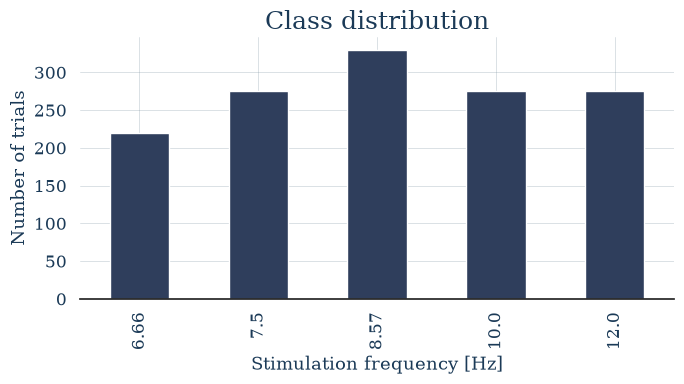

In [15]:
label_counts = pd.Series(labels_float).value_counts().sort_index()
print(label_counts)

ax = label_counts.plot(kind="bar", figsize=(7, 4))
ax.set_xlabel("Stimulation frequency [Hz]")
ax.set_ylabel("Number of trials")
ax.set_title("Class distribution")
plt.tight_layout()
plt.show()

# 6. Channel selection

## 6.1 Why posterior channels?

SSVEP responses are visually evoked and are usually strongest over posterior visual areas. Therefore, this notebook focuses on posterior channels:

```text
O1, O2, P7, P8
```

The term **posterior channels** is used because P7 and P8 are not strictly occipital channels.

## 6.2 Selected channels

In [16]:
print("Posterior channels:", POSTERIOR_CHANNELS)
print("Posterior channel indices:", POSTERIOR_CHANNEL_INDICES)

Posterior channels: ['O1', 'O2', 'P7', 'P8']
Posterior channel indices: [6, 7, 5, 8]


## 6.3 Create posterior signal arrays

In [17]:
X_posterior_raw = X[:, POSTERIOR_CHANNEL_INDICES, :]

print("Raw posterior signal shape:", X_posterior_raw.shape)

Raw posterior signal shape: (1375, 4, 385)


# 7. Preprocessing

## 7.1 Band-pass filtering rationale

A 5–45 Hz band-pass filter is used for spectral visualization and local-SNR analysis. This range removes slow drifts and high-frequency noise while preserving the stimulation frequencies and their first few harmonics.

Zero-phase filtering is used to avoid phase shifts in the filtered signal.

## 7.2 Apply preprocessing

In [23]:
X_filtered = filter_eeg_trials(
    X,
    lowcut=5.0,
    highcut=45.0,
    fs=FS,
    order=4,
    filter_type="cheby",
)

X_posterior_filtered = X_filtered[:, POSTERIOR_CHANNEL_INDICES, :]

print("Filtered posterior signal shape:", X_posterior_filtered.shape)

Filtered posterior signal shape: (1375, 4, 385)


## 7.3 Raw vs filtered signal usage

In this notebook:

- `X_posterior_filtered` is used for PSD visualization and local-SNR baseline.
- `X_posterior_raw` is used for CCA/FBCCA functions, where filtering is controlled explicitly inside the classifier functions.

This avoids accidental double filtering and makes model comparisons clearer.

# 8. Basic exploratory data analysis

## 8.1 Dataset dimensions

In [24]:
dataset_info = pd.DataFrame({
    "quantity": ["trials", "channels", "samples_per_trial", "trial_duration_sec"],
    "value": [n_trials, n_channels, n_samples, trial_duration_sec],
})
dataset_info

,quantity,value
0,trials,1375.000000
1,channels,14.000000
2,samples_per_trial,385.000000
3,trial_duration_sec,3.007812


## 8.2 Label distribution

In [25]:
label_distribution_df = (
    pd.Series(labels_float)
    .value_counts()
    .sort_index()
    .rename_axis("frequency_hz")
    .reset_index(name="n_trials")
)
label_distribution_df

,frequency_hz,n_trials
0,6.66,220
1,7.50,275
2,8.57,330
3,10.00,275
4,12.00,275


## 8.3 Example EEG trial in time domain

A raw EEG trial is difficult to interpret directly in the time domain. SSVEP analysis is therefore usually performed in the frequency domain.

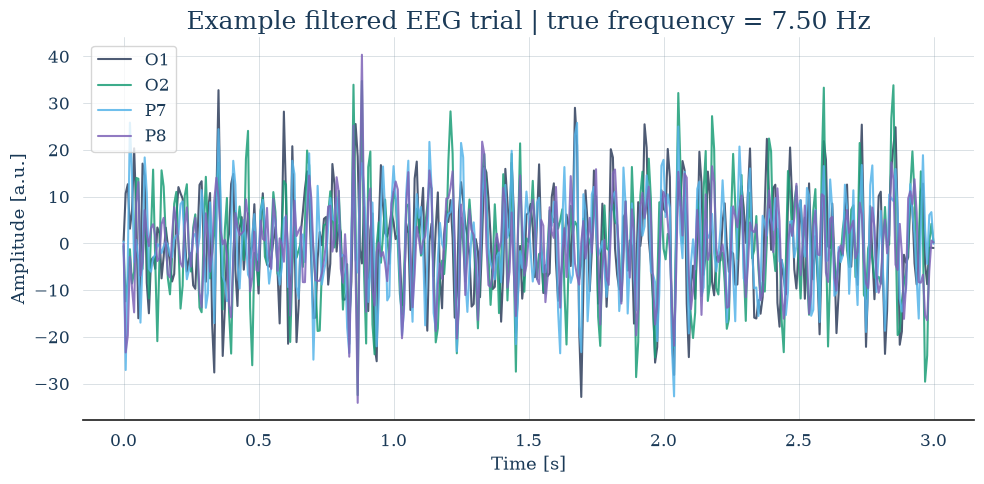

In [26]:
example_trial_idx = 0
example_trial = X_posterior_filtered[example_trial_idx]
example_label = labels_float[example_trial_idx]
time = np.arange(example_trial.shape[1]) / FS

plt.figure(figsize=(10, 5))
for ch_idx, ch_name in enumerate(POSTERIOR_CHANNELS):
    plt.plot(time, example_trial[ch_idx], label=ch_name, alpha=0.85)

plt.title(f"Example filtered EEG trial | true frequency = {example_label:.2f} Hz")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude [a.u.]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Spectral analysis using Welch PSD

## 9.1 Why Welch method?

Power Spectral Density (PSD) shows how signal power is distributed across frequencies. For SSVEP, the expected pattern is increased power near the stimulation frequency and its harmonics. Welch's method reduces the variance of the PSD estimate by averaging periodograms across segments.

## 9.2 Single-trial PSD

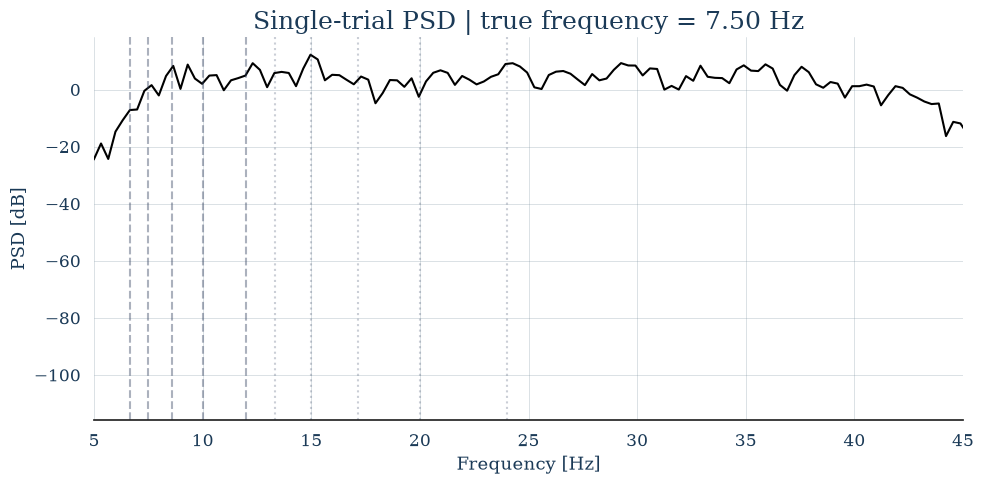

In [27]:
trial_idx = 0
trial = X_posterior_filtered[trial_idx]
current_label = labels_float[trial_idx]

freqs, psd = compute_trial_mean_psd(
    trial=trial,
    fs=FS,
    nperseg=trial.shape[1],
)
psd_db = 10 * np.log10(psd + 1e-12)

plt.figure(figsize=(10, 5))
plt.plot(freqs, psd_db, color="black", linewidth=1.5)

for f in TARGET_FREQS_ALL:
    plt.axvline(f, linestyle="--", alpha=0.4)
    if 2 * f <= 45:
        plt.axvline(2 * f, linestyle=":", alpha=0.25)

plt.xlim(5, 45)
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [dB]")
plt.title(f"Single-trial PSD | true frequency = {current_label:.2f} Hz")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9.3 Class-wise median PSD

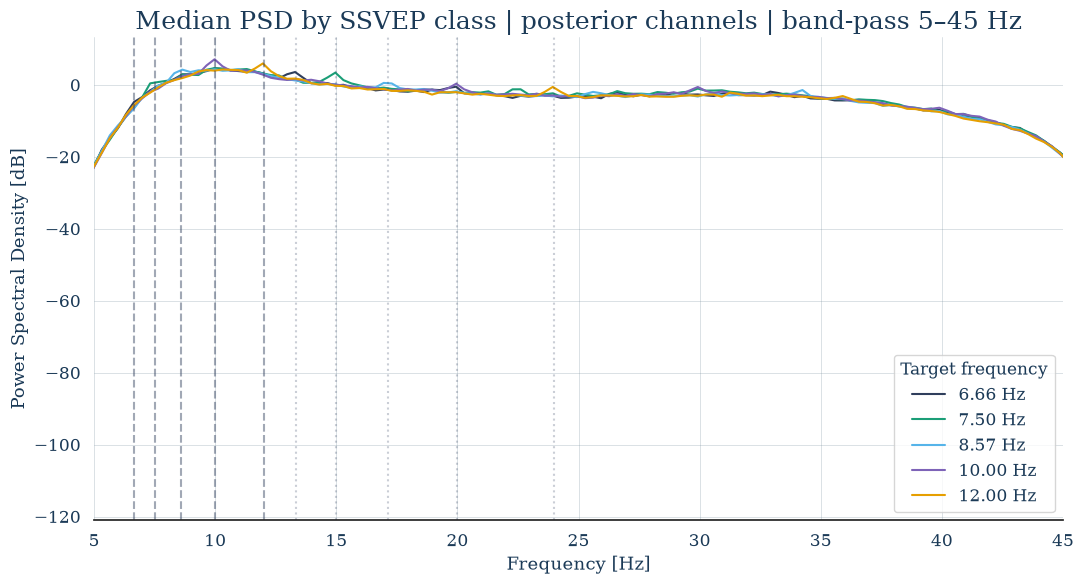

In [28]:
unique_labels = np.sort(np.unique(labels_float))

plt.figure(figsize=(11, 6))

for lab in unique_labels:
    X_lab = X_posterior_filtered[labels_float == lab]
    psds_db = []

    for trial in X_lab:
        freqs, trial_psd = compute_trial_mean_psd(
            trial=trial,
            fs=FS,
            nperseg=trial.shape[1],
        )
        psds_db.append(10 * np.log10(trial_psd + 1e-12))

    class_psd_db = np.median(psds_db, axis=0)
    plt.plot(freqs, class_psd_db, linewidth=1.5, label=f"{lab:.2f} Hz")

for f in TARGET_FREQS_ALL:
    plt.axvline(x=f, linestyle="--", alpha=0.45)
    if 2 * f <= 45:
        plt.axvline(x=2 * f, linestyle=":", alpha=0.25)

plt.title("Median PSD by SSVEP class | posterior channels | band-pass 5–45 Hz")
plt.xlim(5, 45)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power Spectral Density [dB]")
plt.legend(title="Target frequency")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9.4 PSD interpretation

The class-wise PSD plot should be interpreted qualitatively. Local peaks near the target frequencies or harmonics indicate that SSVEP-related components are present. However, strong overlap between class-wise spectra means that PSD visualization alone is not sufficient for reliable classification. This motivates local SNR, CCA and FBCCA analysis.

# 10. Local SNR analysis

## 10.1 Definition of local SNR

Local SNR compares the spectral power at a target frequency with the neighboring spectral background. In this notebook, local SNR is used both as an exploratory feature and as a simple baseline classifier.

## 10.2 SNR function

The SNR function was defined in section 4.2. It expects **linear PSD values**, not dB-transformed values.

## 10.3 SNR per trial and target frequency

In [29]:
def build_snr_dataframe(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata: pd.DataFrame | None = None,
    noise_width: int = 2,
    skip_width: int = 1,
) -> pd.DataFrame:
    """Builds a trial-level SNR table for all target frequencies."""
    rows = []

    for trial_idx, trial in enumerate(trials):
        freqs, trial_psd = compute_trial_mean_psd(
            trial=trial,
            fs=fs,
            nperseg=trial.shape[1],
        )

        result = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
        }
        result = add_metadata_to_result(result, metadata, trial_idx)

        for target_freq in target_freqs:
            snr, snr_db = compute_snr_at_freq(
                freqs=freqs,
                psd=trial_psd,
                target_freq=float(target_freq),
                noise_width=noise_width,
                skip_width=skip_width,
            )
            result[f"SNR_{target_freq:.2f}"] = snr
            result[f"SNRdB_{target_freq:.2f}"] = snr_db

        rows.append(result)

    snr_df = pd.DataFrame(rows)
    snr_columns = [f"SNR_{freq:.2f}" for freq in target_freqs]
    best_col = snr_df[snr_columns].idxmax(axis=1)

    snr_df["predicted_label"] = best_col.str.replace("SNR_", "", regex=False).astype(float)
    snr_df["correct"] = np.isclose(
        snr_df["true_label"].astype(float),
        snr_df["predicted_label"].astype(float),
        atol=0.01,
    )

    return snr_df


snr_df_5 = build_snr_dataframe(
    trials=X_posterior_filtered,
    true_labels=labels_float,
    target_freqs=TARGET_FREQS_ALL,
    fs=FS,
    metadata=metadata,
)

snr_df_5.head()

,trial,true_label,subject,session,run,SNR_6.66,SNRdB_6.66,SNR_7.50,SNRdB_7.50,SNR_8.57,SNRdB_8.57,SNR_10.00,SNRdB_10.00,SNR_12.00,SNRdB_12.00,predicted_label,correct
0,0,7.50,1,0,0,0.324101,-4.893202,0.563909,-2.487907,2.252037,3.525755,0.499983,-3.010445,1.349386,1.301361,8.57,False
1,1,10.00,1,0,0,0.298016,-5.257601,0.978742,-0.093316,1.907659,2.805008,1.333995,1.251542,0.334686,-4.753620,8.57,False
2,2,8.57,1,0,0,0.664795,-1.773125,1.207245,0.817954,0.735785,-1.332491,4.190394,6.222548,0.252403,-5.979051,10.00,False
3,3,6.66,1,0,0,0.591840,-2.277955,3.277046,5.154826,0.865604,-0.626810,0.637705,-1.953801,0.829554,-0.811553,7.50,False
4,4,12.00,1,0,0,0.120976,-9.173026,1.676652,2.244430,0.586194,-2.319587,0.475585,-3.227719,6.215677,7.934885,12.00,True


## 10.4 SNR-based classifier

The SNR classifier predicts the class with the highest local SNR among candidate frequencies.

## 10.5 SNR results

In [30]:
print_metrics(snr_df_5, "SNR baseline 5-class")
print("Per-class accuracy:")
print(per_class_accuracy(snr_df_5))

SNR baseline 5-class accuracy: 33.53%
SNR baseline 5-class balanced accuracy: 32.64%

              precision    recall  f1-score   support

       10.00      0.364     0.429     0.394       275
       12.00      0.387     0.375     0.381       275
        6.66      0.224     0.155     0.183       220
        7.50      0.292     0.298     0.295       275
        8.57      0.352     0.376     0.364       330

    accuracy                          0.335      1375
   macro avg      0.324     0.326     0.323      1375
weighted avg      0.329     0.335     0.330      1375

Per-class accuracy:
true_label
6.66     0.154545
7.50     0.298182
8.57     0.375758
10.00    0.429091
12.00    0.374545
Name: correct, dtype: float64


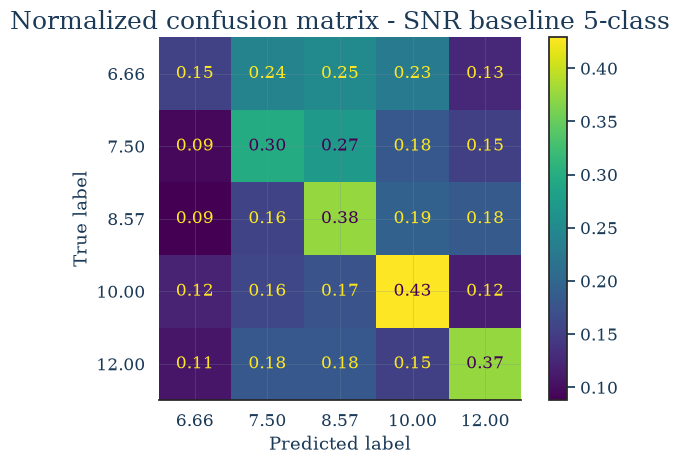

In [31]:
plot_confusion(
    snr_df_5,
    labels_order=TARGET_FREQS_ALL,
    title="Normalized confusion matrix - SNR baseline 5-class",
)

## 10.6 SNR interpretation

The SNR baseline is useful because it confirms whether local frequency-specific information exists in the signal. However, it does not fully exploit the multichannel structure of EEG and does not model the relationship between EEG channels and harmonic reference signals. Therefore, CCA is evaluated next.

# 11. CCA classification

## 11.1 Why CCA?

Canonical Correlation Analysis (CCA) is a standard method for SSVEP frequency recognition. It compares multichannel EEG data with synthetic reference signals generated at candidate stimulation frequencies.

## 11.2 Reference signals

For each candidate frequency, reference signals are generated using sine and cosine waves at the fundamental frequency and its harmonics.

## 11.3 Why sine and cosine?

The SSVEP response phase is not known in advance. Using both sine and cosine allows CCA to represent phase-shifted oscillatory responses as a linear combination of the two components.

## 11.4 CCA prediction function

In [33]:
def cca_predict(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    filter_band: tuple[float, float] | None = None,
    n_harmonics: int = 3,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    metadata: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Predicts SSVEP classes using standard CCA."""
    start_sample = int(trim_start_sec * fs)
    trials_used = trials[:, :, start_sample:] if start_sample > 0 else trials
    n_samples = trials_used.shape[2]

    references = {
        float(freq): generate_reference_signals(
            freq=float(freq),
            n_samples=n_samples,
            fs=fs,
            n_harmonics=n_harmonics,
        )
        for freq in target_freqs
    }

    results = []

    for trial_idx, trial in enumerate(trials_used):
        if filter_band is not None:
            lowcut, highcut = filter_band
            trial_for_cca = filter_trial(
                trial=trial,
                lowcut=lowcut,
                highcut=highcut,
                fs=fs,
                order=filter_order,
                filter_type="butter",
            )
        else:
            trial_for_cca = trial

        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            rho = get_cca_correlation(
                data=trial_for_cca,
                ref=references[target_freq],
            )
            class_scores[target_freq] = rho

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
            "predicted_label": float(predicted_freq),
            "cca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata, trial_idx)

        for freq, score in class_scores.items():
            result[f"CCA_{freq:.2f}"] = float(score)

        results.append(result)

    cca_df = pd.DataFrame(results)
    cca_df["correct"] = np.isclose(
        cca_df["true_label"].astype(float),
        cca_df["predicted_label"].astype(float),
        atol=0.01,
    )

    return cca_df

## 11.5 CCA 5-class results

In [34]:
cca_df_5 = cca_predict(
    trials=X_posterior_raw,
    true_labels=labels_float,
    target_freqs=TARGET_FREQS_ALL,
    fs=FS,
    filter_band=(5, 45),
    n_harmonics=3,
    trim_start_sec=0.0,
    metadata=metadata,
)

print_metrics(cca_df_5, "CCA 5-class")
print("Per-class accuracy:")
print(per_class_accuracy(cca_df_5))

CCA 5-class accuracy: 54.98%
CCA 5-class balanced accuracy: 54.36%

              precision    recall  f1-score   support

       10.00      0.410     0.742     0.528       275
       12.00      0.557     0.571     0.564       275
        6.66      0.550     0.400     0.463       220
        7.50      0.795     0.451     0.575       275
        8.57      0.654     0.555     0.600       330

    accuracy                          0.550      1375
   macro avg      0.593     0.544     0.546      1375
weighted avg      0.597     0.550     0.552      1375

Per-class accuracy:
true_label
6.66     0.400000
7.50     0.450909
8.57     0.554545
10.00    0.741818
12.00    0.570909
Name: correct, dtype: float64


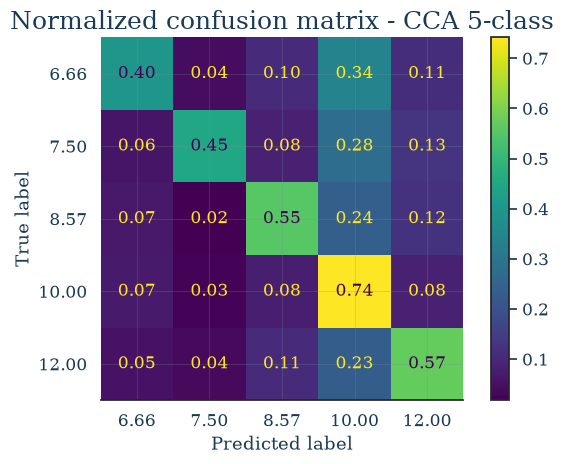

In [32]:
plot_confusion(
    cca_df_5,
    labels_order=TARGET_FREQS_ALL,
    title="Normalized confusion matrix - CCA 5-class",
)

## 11.6 CCA parameter sensitivity

The following cells check whether CCA performance changes with the selected preprocessing band, number of harmonics and beginning-of-trial trimming.

In [35]:
cca_band_candidates = {
    "no_filter": None,
    "5_45": (5, 45),
    "6_45": (6, 45),
    "5_35": (5, 35),
    "6_35": (6, 35),
    "8_30": (8, 30),
}

cca_band_results = []

for name, band in cca_band_candidates.items():
    df = cca_predict(
        trials=X_posterior_raw,
        true_labels=labels_float,
        target_freqs=TARGET_FREQS_ALL,
        fs=FS,
        filter_band=band,
        n_harmonics=3,
        metadata=metadata,
    )
    cca_band_results.append({
        "variant": name,
        "filter_band": band,
        "accuracy": safe_accuracy(df),
        "balanced_accuracy": safe_balanced_accuracy(df),
    })

cca_band_results_df = pd.DataFrame(cca_band_results).sort_values("accuracy", ascending=False)
cca_band_results_df


,variant,filter_band,accuracy,balanced_accuracy
3,5_35,"(5, 35)",0.551273,0.543212
1,5_45,"(5, 45)",0.549818,0.543636
0,no_filter,None,0.549091,0.542788
4,6_35,"(6, 35)",0.548364,0.540424
2,6_45,"(6, 45)",0.541818,0.535576
5,8_30,"(8, 30)",0.538182,0.536727


In [36]:
cca_harmonic_results = []

for n_h in [1, 2, 3, 4, 5]:
    df = cca_predict(
        trials=X_posterior_raw,
        true_labels=labels_float,
        target_freqs=TARGET_FREQS_ALL,
        fs=FS,
        filter_band=(5, 45),
        n_harmonics=n_h,
        metadata=metadata,
    )
    cca_harmonic_results.append({
        "n_harmonics": n_h,
        "accuracy": safe_accuracy(df),
        "balanced_accuracy": safe_balanced_accuracy(df),
    })

cca_harmonic_results_df = pd.DataFrame(cca_harmonic_results).sort_values("accuracy", ascending=False)
cca_harmonic_results_df


,n_harmonics,accuracy,balanced_accuracy
4,5,0.570909,0.566909
3,4,0.565091,0.558606
2,3,0.549818,0.543636
1,2,0.542545,0.533333
0,1,0.416000,0.397879


In [37]:
cca_trim_results = []

for trim in [0.0, 0.25, 0.5, 0.75, 1.0]:
    df = cca_predict(
        trials=X_posterior_raw,
        true_labels=labels_float,
        target_freqs=TARGET_FREQS_ALL,
        fs=FS,
        filter_band=(5, 45),
        n_harmonics=3,
        trim_start_sec=trim,
        metadata=metadata,
    )
    cca_trim_results.append({
        "trim_start_sec": trim,
        "accuracy": safe_accuracy(df),
        "balanced_accuracy": safe_balanced_accuracy(df),
    })

cca_trim_results_df = pd.DataFrame(cca_trim_results).sort_values("accuracy", ascending=False)
cca_trim_results_df


,trim_start_sec,accuracy,balanced_accuracy
1,0.25,0.563636,0.558061
2,0.50,0.552000,0.546364
3,0.75,0.551273,0.544303
0,0.00,0.549818,0.543636
4,1.00,0.548364,0.542121


## 11.7 CCA interpretation

CCA is expected to improve over the local-SNR baseline because it uses multichannel EEG and compares it with harmonic sine/cosine references. Class-wise accuracy and the confusion matrix should be used to identify weak frequencies.

# 12. FBCCA classification

## 12.1 Why FBCCA?

Filter Bank CCA (FBCCA) extends standard CCA by applying CCA across multiple frequency subbands and combining the resulting correlations using weights. This is useful in SSVEP analysis because relevant information can appear not only at the fundamental stimulation frequency but also at harmonic components.

## 12.2 Filter bank design

The default filter bank used here is:

```text
(5, 45), (10, 45), (15, 45)
```

This is intentionally less aggressive than higher low-cut banks because the MAMEM3 target frequencies are relatively low.

## 12.3 FBCCA weights

The default weights follow the common decreasing-weight rule:

```text
w_m = m^(-1.25) + 0.25
```

The first subband receives the highest weight, while higher subbands receive lower weights.

## 12.4 FBCCA prediction function

In [38]:
def fbcca_predict(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    filter_bands: list[tuple[float, float]] | None = None,
    n_harmonics: int = 3,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    metadata: pd.DataFrame | None = None,
    weights: np.ndarray | None = None,
) -> pd.DataFrame:
    """Predicts SSVEP classes using simplified FBCCA."""
    if filter_bands is None:
        filter_bands = [(5, 45), (10, 45), (15, 45)]

    start_sample = int(trim_start_sec * fs)
    trials_used = trials[:, :, start_sample:] if start_sample > 0 else trials
    n_samples = trials_used.shape[2]

    references = {
        float(freq): generate_reference_signals(
            freq=float(freq),
            n_samples=n_samples,
            fs=fs,
            n_harmonics=n_harmonics,
        )
        for freq in target_freqs
    }

    if weights is None:
        weights = np.array([
            (band_idx + 1) ** (-1.25) + 0.25
            for band_idx in range(len(filter_bands))
        ])
    else:
        weights = np.asarray(weights)

    results = []

    for trial_idx, trial in enumerate(trials_used):
        filtered_subbands = []

        # Filtering does not depend on target frequency, so it is done once per subband.
        for lowcut, highcut in filter_bands:
            filtered_trial = filter_trial(
                trial=trial,
                lowcut=lowcut,
                highcut=highcut,
                fs=fs,
                order=filter_order,
                filter_type="butter",
            )
            filtered_subbands.append(filtered_trial)

        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            subband_scores = []

            for filtered_trial in filtered_subbands:
                rho = get_cca_correlation(
                    data=filtered_trial,
                    ref=references[target_freq],
                )
                subband_scores.append(rho ** 2)

            final_score = np.dot(np.array(subband_scores), weights[:len(subband_scores)])
            class_scores[target_freq] = final_score

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
            "predicted_label": float(predicted_freq),
            "fbcca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata, trial_idx)

        for freq, score in class_scores.items():
            result[f"FBCCA_{freq:.2f}"] = float(score)

        results.append(result)

    fbcca_df = pd.DataFrame(results)
    fbcca_df["correct"] = np.isclose(
        fbcca_df["true_label"].astype(float),
        fbcca_df["predicted_label"].astype(float),
        atol=0.01,
    )

    return fbcca_df

## 12.5 FBCCA 5-class results

In [39]:
DEFAULT_FBCCA_BANDS = [(5, 45), (10, 45), (15, 45)]

fbcca_df_5 = fbcca_predict(
    trials=X_posterior_raw,
    true_labels=labels_float,
    target_freqs=TARGET_FREQS_ALL,
    fs=FS,
    filter_bands=DEFAULT_FBCCA_BANDS,
    n_harmonics=3,
    trim_start_sec=0.0,
    metadata=metadata,
)

print_metrics(fbcca_df_5, "FBCCA 5-class")
print("Per-class accuracy:")
print(per_class_accuracy(fbcca_df_5))

FBCCA 5-class accuracy: 55.64%
FBCCA 5-class balanced accuracy: 55.11%

              precision    recall  f1-score   support

       10.00      0.434     0.716     0.540       275
       12.00      0.535     0.647     0.586       275
        6.66      0.503     0.405     0.448       220
        7.50      0.810     0.451     0.579       275
        8.57      0.686     0.536     0.602       330

    accuracy                          0.556      1375
   macro avg      0.594     0.551     0.551      1375
weighted avg      0.601     0.556     0.557      1375

Per-class accuracy:
true_label
6.66     0.404545
7.50     0.450909
8.57     0.536364
10.00    0.716364
12.00    0.647273
Name: correct, dtype: float64


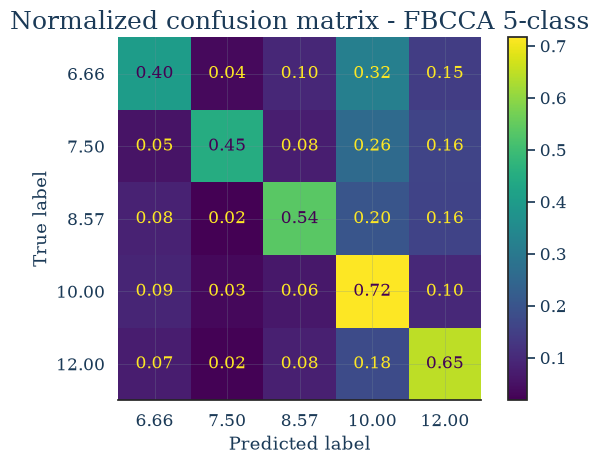

In [40]:
plot_confusion(
    fbcca_df_5,
    labels_order=TARGET_FREQS_ALL,
    title="Normalized confusion matrix - FBCCA 5-class",
)

## 12.6 FBCCA variant comparison

In [39]:
filter_bank_variants = {
    "5_10_15_to_45": [(5, 45), (10, 45), (15, 45)],
    "5_8_12_to_45": [(5, 45), (8, 45), (12, 45)],
    "5_10_15_to_35": [(5, 35), (10, 35), (15, 35)],
    "6_14_22_to_45": [(6, 45), (14, 45), (22, 45)],
    "6_14_to_45": [(6, 45), (14, 45)],
}

fbcca_variant_results = []

for name, bands in filter_bank_variants.items():
    df = fbcca_predict(
        trials=X_posterior_raw,
        true_labels=labels_float,
        target_freqs=TARGET_FREQS_ALL,
        fs=FS,
        filter_bands=bands,
        n_harmonics=3,
        metadata=metadata,
    )

    fbcca_variant_results.append({
        "variant": name,
        "filter_bands": bands,
        "accuracy": safe_accuracy(df),
        "balanced_accuracy": safe_balanced_accuracy(df),
    })

fbcca_variant_results_df = pd.DataFrame(fbcca_variant_results).sort_values("accuracy", ascending=False)
fbcca_variant_results_df


,variant,filter_bands,accuracy,balanced_accuracy
2,5_10_15_to_35,"[(5, 35), (10, 35), (15, 35)]",0.573818,0.567818
4,6_14_to_45,"[(6, 45), (14, 45)]",0.562182,0.551636
1,5_8_12_to_45,"[(5, 45), (8, 45), (12, 45)]",0.558545,0.553697
0,5_10_15_to_45,"[(5, 45), (10, 45), (15, 45)]",0.556364,0.551091
3,6_14_22_to_45,"[(6, 45), (14, 45), (22, 45)]",0.545455,0.530667


In [40]:
fbcca_harmonic_results = []

for n_h in [1, 2, 3, 4, 5]:
    df = fbcca_predict(
        trials=X_posterior_raw,
        true_labels=labels_float,
        target_freqs=TARGET_FREQS_ALL,
        fs=FS,
        filter_bands=DEFAULT_FBCCA_BANDS,
        n_harmonics=n_h,
        metadata=metadata,
    )

    fbcca_harmonic_results.append({
        "n_harmonics": n_h,
        "accuracy": safe_accuracy(df),
        "balanced_accuracy": safe_balanced_accuracy(df),
    })

fbcca_harmonic_results_df = pd.DataFrame(fbcca_harmonic_results).sort_values("accuracy", ascending=False)
fbcca_harmonic_results_df


,n_harmonics,accuracy,balanced_accuracy
3,4,0.573818,0.568364
4,5,0.568000,0.568303
2,3,0.556364,0.551091
1,2,0.544000,0.534242
0,1,0.397091,0.383697


## 12.7 FBCCA interpretation

FBCCA should be compared with standard CCA using the same channels and the same candidate frequencies. If FBCCA improves only slightly, this suggests that filter-bank information is helpful but not sufficient to solve weak class separability.

# 13. Advanced supervised SSVEP methods

The previous sections used methods that can work without subject-specific calibration: SNR, standard CCA and FBCCA. This section adds more advanced methods that use either narrower frequency-domain assumptions or training data from the same dataset.

Implemented methods:

- **Narrow-band CCA / NB-CCA** — CCA applied around the fundamental frequency and selected harmonics.
- **IT-CCA** — individual-template CCA using class templates averaged from training trials.
- **Simplified eCCA** — an extended CCA-style score combining sine/cosine references and individual templates.
- **MsetCCA-inspired method** — multi-set CCA-inspired class reference learning from training trials.
- **TRCA** — task-related component analysis using class-specific spatial filters.
- **eTRCA** — ensemble TRCA using filters learned for all classes.

Important methodological note: IT-CCA, eCCA, MsetCCA, TRCA and eTRCA use training data. Therefore, they are evaluated with stratified cross-validation to avoid training-test leakage. These implementations are educational and transparent; for publication-level benchmarking, compare them with reference implementations such as MOABB or SSVEP Analysis Toolbox.


## 13.1 Advanced-method configuration

By default, this section evaluates the 3-class setup because earlier analysis showed that 8.57, 10.00 and 12.00 Hz are the most separable frequencies in this notebook. Change `ADVANCED_TARGET_FREQS` to run the same methods on the 4-class or 5-class setup.


In [41]:
# Advanced supervised methods configuration.

# Recommended default based on earlier frequency-selection analysis.
ADVANCED_TARGET_FREQS = [8.57, 10.00, 12.00]

# 4-class setup without 6.66 Hz.
# ADVANCED_TARGET_FREQS = [7.50, 8.57, 10.00, 12.00]

# Full 5-class setup.
# ADVANCED_TARGET_FREQS = [6.66, 7.50, 8.57, 10.00, 12.00]

ADVANCED_N_SPLITS = 5
ADVANCED_FILTER_BAND = (5, 45)
ADVANCED_N_HARMONICS = 3
ADVANCED_TRIM_START_SEC = 0.0

X_advanced, labels_advanced, metadata_advanced = select_frequency_subset(
    trials=X_posterior_raw,
    labels=labels,
    metadata=metadata,
    selected_freqs=ADVANCED_TARGET_FREQS,
)

print("Advanced target frequencies:", ADVANCED_TARGET_FREQS)
print("X_advanced shape:", X_advanced.shape)
print("Class distribution:")
print(pd.Series(labels_advanced).value_counts().sort_index())


Advanced target frequencies: [8.57, 10.0, 12.0]
X_advanced shape: (880, 4, 385)
Class distribution:
8.57     330
10.00    275
12.00    275
Name: count, dtype: int64


## 13.2 Cross-validation and template utilities

The following helper functions are shared by all training-based methods. They implement a consistent stratified cross-validation protocol and class-template construction.


In [42]:
def trim_trials(
    trials: np.ndarray,
    fs: int,
    trim_start_sec: float = 0.0,
) -> np.ndarray:
    """Removes the first part of each trial when trim_start_sec > 0."""
    start_sample = int(trim_start_sec * fs)
    return trials[:, :, start_sample:] if start_sample > 0 else trials


def preprocess_trials_for_model(
    trials: np.ndarray,
    fs: int,
    filter_band: tuple[float, float] | None = None,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
) -> np.ndarray:
    """Trims trials and optionally applies one Butterworth band-pass filter to each trial."""
    trials_used = trim_trials(trials, fs=fs, trim_start_sec=trim_start_sec)

    if filter_band is None:
        return np.asarray(trials_used, dtype=float)

    lowcut, highcut = filter_band
    filtered = np.zeros_like(trials_used, dtype=float)

    for trial_idx, trial in enumerate(trials_used):
        filtered[trial_idx] = filter_trial(
            trial=trial,
            lowcut=lowcut,
            highcut=highcut,
            fs=fs,
            order=filter_order,
            filter_type="butter",
        )

    return filtered


def build_class_templates(
    trials: np.ndarray,
    labels: np.ndarray,
    target_freqs: list[float],
) -> dict[float, np.ndarray]:
    """Builds one average EEG template per class from training trials."""
    labels_float = labels.astype(float)
    templates = {}

    for freq in target_freqs:
        freq = float(freq)
        class_trials = trials[np.isclose(labels_float, freq, atol=0.01)]

        if class_trials.shape[0] == 0:
            raise ValueError(f"No training trials found for frequency {freq} Hz.")

        templates[freq] = class_trials.mean(axis=0)

    return templates


def safe_corrcoef(x: np.ndarray, y: np.ndarray) -> float:
    """Returns Pearson correlation for two 1-D arrays; returns 0 for degenerate inputs."""
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()

    if x.size != y.size:
        raise ValueError("x and y must have the same length.")
    if np.std(x) == 0 or np.std(y) == 0:
        return 0.0

    corr = np.corrcoef(x, y)[0, 1]
    return 0.0 if np.isnan(corr) else float(corr)


def make_cv_labels(labels: np.ndarray) -> np.ndarray:
    """Converts float stimulation frequencies to categorical labels for StratifiedKFold."""
    return format_frequency_labels(labels).to_numpy()


def call_method_with_supported_args(method_fn, **kwargs):
    """Calls a train/test method using only keyword arguments supported by its signature.

    This prevents errors such as:
    TypeError: <method>() got an unexpected keyword argument 'metadata'
    when different advanced methods use slightly different parameter names.
    """
    import inspect

    signature = inspect.signature(method_fn)
    supported_kwargs = {
        key: value
        for key, value in kwargs.items()
        if key in signature.parameters
    }
    return method_fn(**supported_kwargs)


def evaluate_cv_template_method(
    method_fn,
    trials: np.ndarray,
    labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata: pd.DataFrame | None = None,
    n_splits: int = 5,
    random_state: int = RANDOM_STATE,
    **method_kwargs,
) -> pd.DataFrame:
    """Evaluates a train/test SSVEP method with stratified K-fold cross-validation.

    Frequency labels are stored as floats in this project, e.g. 8.57, 10.00 and 12.00.
    sklearn's StratifiedKFold treats non-integer floats as continuous targets, so labels
    are converted to categorical strings for splitting. The original float labels are
    still passed to the train/test methods because they represent actual frequencies.
    """
    labels_float = np.asarray(labels, dtype=float)
    labels_cv = make_cv_labels(labels_float)

    class_counts = pd.Series(labels_cv).value_counts()
    min_class_count = int(class_counts.min())
    effective_n_splits = min(int(n_splits), min_class_count)

    if effective_n_splits < 2:
        raise ValueError(
            "At least two trials per selected class are required for stratified CV."
        )

    if effective_n_splits != n_splits:
        print(
            f"Requested n_splits={n_splits}, but the smallest class has only "
            f"{min_class_count} trials. Using n_splits={effective_n_splits}."
        )

    metadata_reset = metadata.reset_index(drop=True) if metadata is not None else None

    skf = StratifiedKFold(
        n_splits=effective_n_splits,
        shuffle=True,
        random_state=random_state,
    )

    fold_results = []
    X_dummy = np.zeros(len(labels_cv))

    for fold_idx, (train_idx, test_idx) in enumerate(
        skf.split(X_dummy, labels_cv),
        start=1,
    ):
        metadata_test = (
            metadata_reset.iloc[test_idx].reset_index(drop=True)
            if metadata_reset is not None
            else None
        )

        fold_df = call_method_with_supported_args(
            method_fn,
            X_train=trials[train_idx],
            y_train=labels_float[train_idx],
            X_test=trials[test_idx],
            y_test=labels_float[test_idx],
            target_freqs=target_freqs,
            fs=fs,
            metadata_test=metadata_test,
            metadata=metadata_test,
            **method_kwargs,
        )

        fold_df.insert(0, "fold", fold_idx)
        fold_df.insert(1, "trial_global_index", test_idx)
        fold_results.append(fold_df)

    return pd.concat(fold_results, ignore_index=True)


## 13.2b Subject-dependent cross-validation (fix)

`evaluate_cv_template_method` above (unchanged, kept for comparison) pools trials from
all subjects before doing `StratifiedKFold`. For template/filter-based methods this means
a class "template" or TRCA spatial filter can be learned from a training fold that mixes
different people, which dilutes or destroys the trial-to-trial reproducibility these
methods rely on.

`evaluate_cv_template_method_per_subject` below fixes this: it loops over each subject,
runs stratified K-fold **only on that subject's own trials**, and concatenates the
per-subject fold results. This matches the standard "subject-dependent" (a.k.a.
within-subject calibration) evaluation protocol used in the SSVEP literature for
TRCA/eTRCA/IT-CCA/MsetCCA benchmarks. It requires `metadata` with a `subject` column,
which is already attached throughout this notebook.


In [43]:
def evaluate_cv_template_method_per_subject(
    method_fn,
    trials: np.ndarray,
    labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata: pd.DataFrame | None = None,
    n_splits: int = 5,
    random_state: int = RANDOM_STATE,
    min_trials_per_class: int = 2,
    verbose: bool = True,
    **method_kwargs,
) -> pd.DataFrame:
    """Evaluates a train/test SSVEP method with subject-dependent stratified K-fold CV.

    Unlike `evaluate_cv_template_method`, this function never mixes trials from different
    subjects between train and test, and never learns a template/filter from more than one
    subject's data. Each subject is calibrated and evaluated using only their own trials,
    matching the standard subject-dependent SSVEP benchmarking protocol.

    Subjects with fewer than `min_trials_per_class` trials in their smallest class are
    skipped (with a warning) rather than causing a hard failure, since CV needs at least
    two trials per class per fold.
    """
    if metadata is None or "subject" not in metadata.columns:
        raise ValueError(
            "metadata with a 'subject' column is required for per-subject CV."
        )

    labels_float = np.asarray(labels, dtype=float)
    metadata_reset = metadata.reset_index(drop=True)
    subjects = metadata_reset["subject"].to_numpy()

    fold_results = []

    for subject_id in np.unique(subjects):
        subject_mask = subjects == subject_id
        X_subject = trials[subject_mask]
        y_subject = labels_float[subject_mask]
        meta_subject = metadata_reset.loc[subject_mask].reset_index(drop=True)

        labels_cv = make_cv_labels(y_subject)
        class_counts = pd.Series(labels_cv).value_counts()
        min_class_count = int(class_counts.min()) if len(class_counts) > 0 else 0

        if min_class_count < min_trials_per_class:
            if verbose:
                print(
                    f"Skipping subject {subject_id}: smallest class has only "
                    f"{min_class_count} trial(s), need at least {min_trials_per_class}."
                )
            continue

        effective_n_splits = min(int(n_splits), min_class_count)
        if effective_n_splits < 2:
            if verbose:
                print(f"Skipping subject {subject_id}: not enough trials for CV.")
            continue

        skf = StratifiedKFold(
            n_splits=effective_n_splits,
            shuffle=True,
            random_state=random_state,
        )
        X_dummy = np.zeros(len(labels_cv))

        for fold_idx, (train_idx, test_idx) in enumerate(
            skf.split(X_dummy, labels_cv),
            start=1,
        ):
            metadata_test = meta_subject.iloc[test_idx].reset_index(drop=True)

            fold_df = call_method_with_supported_args(
                method_fn,
                X_train=X_subject[train_idx],
                y_train=y_subject[train_idx],
                X_test=X_subject[test_idx],
                y_test=y_subject[test_idx],
                target_freqs=target_freqs,
                fs=fs,
                metadata_test=metadata_test,
                metadata=metadata_test,
                **method_kwargs,
            )

            # metadata_test already carries a "subject" column (added inside
            # method_fn via add_metadata_to_result), so assign instead of using
            # .insert() here to avoid a duplicate-column error; assignment
            # overwrites the column if present and creates it if not.
            fold_df["subject"] = subject_id
            fold_df["fold"] = fold_idx
            leading_cols = [c for c in ["subject", "fold"] if c in fold_df.columns]
            other_cols = [c for c in fold_df.columns if c not in leading_cols]
            fold_df = fold_df[leading_cols + other_cols]
            fold_results.append(fold_df)

    if not fold_results:
        raise ValueError("No subject produced any valid CV fold; check class counts.")

    return pd.concat(fold_results, ignore_index=True)


## 13.3 Narrow-band CCA / NB-CCA

Narrow-band CCA tests a stricter spectral assumption than standard CCA. Instead of filtering the entire broad SSVEP band, it applies CCA in narrow bands around the expected frequency components: `f`, `2f`, `3f`, etc. This may help when broad-band CCA includes too much unrelated EEG background activity.

This method does not use training data, but it is included here because it was one of the proposed extensions for improving the final result.


In [44]:
def generate_single_harmonic_reference(
    freq: float,
    harmonic: int,
    n_samples: int,
    fs: int,
) -> np.ndarray:
    """Generates sine/cosine reference for one harmonic of a target frequency."""
    t = np.arange(n_samples) / fs
    component_freq = harmonic * freq

    return np.vstack([
        np.sin(2 * np.pi * component_freq * t),
        np.cos(2 * np.pi * component_freq * t),
    ])


def narrow_band_cca_predict(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    harmonics: list[int] | None = None,
    band_half_width: float = 1.0,
    low_limit: float = 5.0,
    high_limit: float = 45.0,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    metadata: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Predicts SSVEP class using narrow-band CCA around each harmonic."""
    if harmonics is None:
        harmonics = [1, 2, 3]

    trials_used = trim_trials(trials, fs=fs, trim_start_sec=trim_start_sec)
    n_samples = trials_used.shape[2]
    nyq = 0.5 * fs

    harmonic_weights = np.array([1 / h for h in harmonics], dtype=float)

    results = []

    for trial_idx, trial in enumerate(trials_used):
        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            target_scores = []
            target_weights = []

            for weight, harmonic in zip(harmonic_weights, harmonics):
                center_freq = harmonic * target_freq
                lowcut = max(low_limit, center_freq - band_half_width)
                highcut = min(high_limit, center_freq + band_half_width)

                if lowcut <= 0 or highcut >= nyq or lowcut >= highcut:
                    continue

                filtered_trial = filter_trial(
                    trial=trial,
                    lowcut=lowcut,
                    highcut=highcut,
                    fs=fs,
                    order=filter_order,
                    filter_type="butter",
                )

                ref = generate_single_harmonic_reference(
                    freq=target_freq,
                    harmonic=harmonic,
                    n_samples=n_samples,
                    fs=fs,
                )

                rho = get_cca_correlation(filtered_trial, ref)
                target_scores.append(rho ** 2)
                target_weights.append(weight)

            if len(target_scores) == 0:
                class_scores[target_freq] = 0.0
            else:
                class_scores[target_freq] = float(
                    np.dot(np.array(target_scores), np.array(target_weights))
                )

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
            "predicted_label": float(predicted_freq),
            "nbcca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(
        df["true_label"].astype(float),
        df["predicted_label"].astype(float),
        atol=0.01,
    )
    return df


In [45]:
nbcca_df_advanced = narrow_band_cca_predict(
    trials=X_advanced,
    true_labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    harmonics=[1, 2, 3],
    band_half_width=1.0,
    low_limit=5.0,
    high_limit=45.0,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
    metadata=metadata_advanced,
)

print_metrics(nbcca_df_advanced, "Narrow-band CCA")
per_class_accuracy(nbcca_df_advanced)


Narrow-band CCA accuracy: 63.18%
Narrow-band CCA balanced accuracy: 63.45%

              precision    recall  f1-score   support

       10.00      0.589     0.676     0.629       275
       12.00      0.629     0.636     0.633       275
        8.57      0.682     0.591     0.633       330

    accuracy                          0.632       880
   macro avg      0.633     0.635     0.632       880
weighted avg      0.636     0.632     0.632       880



true_label
8.57     0.590909
10.00    0.676364
12.00    0.636364
Name: correct, dtype: float64

## 13.4 IT-CCA: individual-template CCA

IT-CCA replaces purely sinusoidal references with individual EEG templates estimated from training trials. For each class, the training trials are averaged into a class template. During prediction, the test trial is compared with each template using CCA.

This method is supervised/calibrated: it can use information about the individual structure of SSVEP responses, but it requires training data from the subject or dataset.


In [46]:
def itcca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_band: tuple[float, float] | None = (5, 45),
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
) -> pd.DataFrame:
    """Train/test prediction using individual-template CCA."""
    X_train_p = preprocess_trials_for_model(
        X_train, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )
    X_test_p = preprocess_trials_for_model(
        X_test, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )

    templates = build_class_templates(X_train_p, y_train, target_freqs)

    results = []

    for trial_idx, trial in enumerate(X_test_p):
        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            rho = get_cca_correlation(trial, templates[target_freq])
            class_scores[target_freq] = rho ** 2

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "itcca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [47]:
itcca_df_advanced = evaluate_cv_template_method(
    method_fn=itcca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(itcca_df_advanced, "IT-CCA")
per_class_accuracy(itcca_df_advanced)


IT-CCA accuracy: 39.32%
IT-CCA balanced accuracy: 38.99%

              precision    recall  f1-score   support

       10.00      0.349     0.375     0.361       275
       12.00      0.366     0.353     0.359       275
        8.57      0.456     0.442     0.449       330

    accuracy                          0.393       880
   macro avg      0.390     0.390     0.390       880
weighted avg      0.395     0.393     0.394       880



true_label
8.57     0.442424
10.00    0.374545
12.00    0.352727
Name: correct, dtype: float64

### 13.4b IT-CCA — subject-dependent calibration (fixed)

Same method, evaluated with `evaluate_cv_template_method_per_subject` instead of the
subject-mixed version above. Compare `itcca_df_advanced["correct"].mean()` (v3, buggy)
with `itcca_df_advanced_subjectcv["correct"].mean()` (fixed) to see the effect directly.


In [48]:
itcca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=itcca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(itcca_df_advanced_subjectcv, "IT-CCA (subject-dependent)")
per_class_accuracy(itcca_df_advanced_subjectcv)


IT-CCA (subject-dependent) accuracy: 37.50%
IT-CCA (subject-dependent) balanced accuracy: 37.56%

              precision    recall  f1-score   support

       10.00      0.348     0.378     0.362       275
       12.00      0.349     0.382     0.365       275
        8.57      0.432     0.367     0.397       330

    accuracy                          0.375       880
   macro avg      0.376     0.376     0.375       880
weighted avg      0.380     0.375     0.376       880



true_label
8.57     0.366667
10.00    0.378182
12.00    0.381818
Name: correct, dtype: float64

## 13.5 Simplified eCCA: extended CCA-style scoring

Extended CCA methods combine sinusoidal reference information with individual EEG templates. The exact variants differ across papers and toolboxes. In this notebook, a transparent eCCA-style score is implemented as a combination of three CCA terms:

1. test EEG vs sinusoidal reference,
2. test EEG vs class template,
3. class template vs sinusoidal reference.

This is useful as an interpretable extension between standard CCA and fully supervised template methods. Treat it as a simplified educational implementation rather than a drop-in replacement for every published eCCA variant.


In [49]:
def ecca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_band: tuple[float, float] | None = (5, 45),
    n_harmonics: int = 3,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
) -> pd.DataFrame:
    """Train/test prediction using a simplified extended CCA-style score."""
    X_train_p = preprocess_trials_for_model(
        X_train, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )
    X_test_p = preprocess_trials_for_model(
        X_test, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )

    n_samples = X_test_p.shape[2]
    templates = build_class_templates(X_train_p, y_train, target_freqs)

    references = {
        float(freq): generate_reference_signals(
            freq=float(freq),
            n_samples=n_samples,
            fs=fs,
            n_harmonics=n_harmonics,
        )
        for freq in target_freqs
    }

    results = []

    for trial_idx, trial in enumerate(X_test_p):
        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            template = templates[target_freq]
            ref = references[target_freq]

            rho_test_ref = get_cca_correlation(trial, ref)
            rho_test_template = get_cca_correlation(trial, template)
            rho_template_ref = get_cca_correlation(template, ref)

            score = (
                rho_test_ref ** 2
                + rho_test_template ** 2
                + rho_template_ref ** 2
            )
            class_scores[target_freq] = float(score)

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "ecca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [50]:
ecca_df_advanced = evaluate_cv_template_method(
    method_fn=ecca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    n_harmonics=ADVANCED_N_HARMONICS,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(ecca_df_advanced, "Simplified eCCA")
per_class_accuracy(ecca_df_advanced)


Simplified eCCA accuracy: 49.89%
Simplified eCCA balanced accuracy: 50.77%

              precision    recall  f1-score   support

       10.00      0.414     0.913     0.570       275
       12.00      0.779     0.244     0.371       275
        8.57      0.644     0.367     0.467       330

    accuracy                          0.499       880
   macro avg      0.612     0.508     0.469       880
weighted avg      0.614     0.499     0.469       880



true_label
8.57     0.366667
10.00    0.912727
12.00    0.243636
Name: correct, dtype: float64

### 13.5b Simplified eCCA — subject-dependent calibration (fixed)


In [51]:
ecca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=ecca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    n_harmonics=ADVANCED_N_HARMONICS,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(ecca_df_advanced_subjectcv, "Simplified eCCA (subject-dependent)")
per_class_accuracy(ecca_df_advanced_subjectcv)


Simplified eCCA (subject-dependent) accuracy: 54.09%
Simplified eCCA (subject-dependent) balanced accuracy: 54.42%

              precision    recall  f1-score   support

       10.00      0.491     0.716     0.583       275
       12.00      0.616     0.425     0.503       275
        8.57      0.561     0.491     0.523       330

    accuracy                          0.541       880
   macro avg      0.556     0.544     0.536       880
weighted avg      0.556     0.541     0.536       880



true_label
8.57     0.490909
10.00    0.716364
12.00    0.425455
Name: correct, dtype: float64

## 13.6 MsetCCA-inspired class reference learning

Multi-set CCA learns reference information from multiple training trials rather than using only ideal sine/cosine signals. A full MsetCCA implementation can become computationally heavy when each class has many trials, because the block covariance problem grows with the number of training trials.

The implementation below is a compact MsetCCA-inspired version:

- a limited number of training trials is selected for each class,
- a block covariance problem is solved to find trial-specific projections,
- projected training trials are averaged into a 1-D class reference,
- test EEG is compared with each learned class reference using CCA.

This gives a practical notebook-level demonstration of the idea without turning the EDA into a heavy algorithm-engineering project.


In [52]:
def solve_generalized_eigen_max(
    A: np.ndarray,
    B: np.ndarray,
    reg: float = 1e-6,
) -> np.ndarray:
    """Solves a generalized eigenproblem and returns the eigenvector with largest eigenvalue."""
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    A = 0.5 * (A + A.T)
    B = 0.5 * (B + B.T)
    B = B + reg * np.eye(B.shape[0])

    try:
        eigvals, eigvecs = eigh(A, B)
    except Exception:
        eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(B) @ A)

    best_idx = int(np.argmax(np.real(eigvals)))
    return np.real(eigvecs[:, best_idx])


def learn_msetcca_reference(
    class_trials: np.ndarray,
    max_trials: int = 20,
    random_state: int = RANDOM_STATE,
    reg: float = 1e-6,
) -> np.ndarray:
    """Learns a 1-D class reference using a compact MsetCCA-inspired block covariance problem."""
    rng = np.random.default_rng(random_state)
    trials = np.asarray(class_trials, dtype=float)

    if trials.shape[0] > max_trials:
        selected = rng.choice(trials.shape[0], size=max_trials, replace=False)
        trials = trials[np.sort(selected)]

    # Trial-wise channel centering.
    trials = trials - trials.mean(axis=2, keepdims=True)

    n_trials, n_channels, n_samples = trials.shape
    dim = n_trials * n_channels

    A = np.zeros((dim, dim), dtype=float)  # inter-set covariance
    B = np.zeros((dim, dim), dtype=float)  # block-diagonal within-set covariance

    for i in range(n_trials):
        Xi = trials[i]
        i0 = i * n_channels
        i1 = (i + 1) * n_channels

        B[i0:i1, i0:i1] = Xi @ Xi.T / max(n_samples - 1, 1)

        for j in range(n_trials):
            if i == j:
                continue

            Xj = trials[j]
            j0 = j * n_channels
            j1 = (j + 1) * n_channels
            A[i0:i1, j0:j1] = Xi @ Xj.T / max(n_samples - 1, 1)

    v = solve_generalized_eigen_max(A, B, reg=reg)
    W = v.reshape(n_trials, n_channels)

    projected_trials = np.array([
        W[i] @ trials[i]
        for i in range(n_trials)
    ])

    reference = projected_trials.mean(axis=0)
    return reference.reshape(1, -1)


def msetcca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_band: tuple[float, float] | None = (5, 45),
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    max_trials_per_class: int = 20,
) -> pd.DataFrame:
    """Train/test prediction using compact MsetCCA-inspired learned references."""
    X_train_p = preprocess_trials_for_model(
        X_train, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )
    X_test_p = preprocess_trials_for_model(
        X_test, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )

    y_train = y_train.astype(float)
    references = {}

    for freq in target_freqs:
        freq = float(freq)
        class_trials = X_train_p[np.isclose(y_train, freq, atol=0.01)]
        references[freq] = learn_msetcca_reference(
            class_trials=class_trials,
            max_trials=max_trials_per_class,
            random_state=RANDOM_STATE,
        )

    results = []

    for trial_idx, trial in enumerate(X_test_p):
        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            rho = get_cca_correlation(trial, references[target_freq])
            class_scores[target_freq] = rho ** 2

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "msetcca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [53]:
msetcca_df_advanced = evaluate_cv_template_method(
    method_fn=msetcca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
    max_trials_per_class=20,
)

print_metrics(msetcca_df_advanced, "MsetCCA-inspired")
per_class_accuracy(msetcca_df_advanced)


MsetCCA-inspired accuracy: 48.86%
MsetCCA-inspired balanced accuracy: 49.98%

              precision    recall  f1-score   support

       10.00      0.463     0.629     0.533       275
       12.00      0.476     0.549     0.510       275
        8.57      0.561     0.321     0.408       330

    accuracy                          0.489       880
   macro avg      0.500     0.500     0.484       880
weighted avg      0.504     0.489     0.479       880



true_label
8.57     0.321212
10.00    0.629091
12.00    0.549091
Name: correct, dtype: float64

### 13.6b MsetCCA-inspired — subject-dependent calibration (fixed)


In [54]:
msetcca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=msetcca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
    max_trials_per_class=20,
)

print_metrics(msetcca_df_advanced_subjectcv, "MsetCCA-inspired (subject-dependent)")
per_class_accuracy(msetcca_df_advanced_subjectcv)


MsetCCA-inspired (subject-dependent) accuracy: 43.30%
MsetCCA-inspired (subject-dependent) balanced accuracy: 43.78%

              precision    recall  f1-score   support

       10.00      0.425     0.498     0.459       275
       12.00      0.397     0.455     0.424       275
        8.57      0.490     0.361     0.415       330

    accuracy                          0.433       880
   macro avg      0.437     0.438     0.433       880
weighted avg      0.441     0.433     0.432       880



true_label
8.57     0.360606
10.00    0.498182
12.00    0.454545
Name: correct, dtype: float64

> **v5 note:** The implementation and saved outputs in this section are retained as the v4 historical version. A corrected/reference-like TRCA scoring implementation is added in Section 21.2 and should be used for v5 conclusions.

## 13.7 TRCA: task-related component analysis

TRCA learns class-specific spatial filters that maximize the reproducibility of EEG responses across training trials from the same class. This is well suited to SSVEP because the response to the same stimulus frequency should be phase-locked and repeatable across trials.

Compared with CCA/FBCCA, TRCA is not calibration-free. It needs training trials, but it can be much stronger when subject-specific calibration is available.


In [55]:
def learn_trca_filter(
    class_trials: np.ndarray,
    reg: float = 1e-6,
) -> np.ndarray:
    """Learns one TRCA spatial filter for a single class."""
    trials = np.asarray(class_trials, dtype=float)
    trials = trials - trials.mean(axis=2, keepdims=True)

    n_trials, n_channels, _ = trials.shape

    S = np.zeros((n_channels, n_channels), dtype=float)
    Q = np.zeros((n_channels, n_channels), dtype=float)

    for i in range(n_trials):
        Xi = trials[i]
        Q += Xi @ Xi.T

        for j in range(n_trials):
            if i == j:
                continue
            Xj = trials[j]
            S += Xi @ Xj.T

    scale = np.trace(Q) / n_channels if np.trace(Q) > 0 else 1.0
    Q = Q + reg * scale * np.eye(n_channels)

    w = solve_generalized_eigen_max(S, Q, reg=reg)
    norm = np.linalg.norm(w)
    return w / norm if norm > 0 else w


def train_trca_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    target_freqs: list[float],
) -> tuple[dict[float, np.ndarray], dict[float, np.ndarray]]:
    """Learns TRCA templates and class-specific spatial filters."""
    templates = build_class_templates(X_train, y_train, target_freqs)
    filters = {}
    y_train = y_train.astype(float)

    for freq in target_freqs:
        freq = float(freq)
        class_trials = X_train[np.isclose(y_train, freq, atol=0.01)]
        filters[freq] = learn_trca_filter(class_trials)

    return templates, filters


def trca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_band: tuple[float, float] | None = (5, 45),
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
) -> pd.DataFrame:
    """Train/test prediction using TRCA."""
    X_train_p = preprocess_trials_for_model(
        X_train, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )
    X_test_p = preprocess_trials_for_model(
        X_test, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )

    templates, filters = train_trca_model(X_train_p, y_train, target_freqs)

    results = []

    for trial_idx, trial in enumerate(X_test_p):
        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            w = filters[target_freq]
            template = templates[target_freq]

            test_component = w @ trial
            template_component = w @ template
            rho = safe_corrcoef(test_component, template_component)
            class_scores[target_freq] = rho ** 2

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "trca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [56]:
trca_df_advanced = evaluate_cv_template_method(
    method_fn=trca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(trca_df_advanced, "TRCA")
per_class_accuracy(trca_df_advanced)


TRCA accuracy: 34.66%
TRCA balanced accuracy: 34.91%

              precision    recall  f1-score   support

       10.00      0.323     0.356     0.339       275
       12.00      0.342     0.382     0.361       275
        8.57      0.378     0.309     0.340       330

    accuracy                          0.347       880
   macro avg      0.348     0.349     0.347       880
weighted avg      0.350     0.347     0.346       880



true_label
8.57     0.309091
10.00    0.356364
12.00    0.381818
Name: correct, dtype: float64

### 13.7b TRCA — subject-dependent calibration (fixed)

This is the comparison to watch: in v3, subject-mixed TRCA scored ~34.7% (chance = 33.3%).
TRCA's whole premise is that the same person's trials are reproducible; evaluated correctly
per-subject it should behave very differently.


In [57]:
trca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=trca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(trca_df_advanced_subjectcv, "TRCA (subject-dependent)")
per_class_accuracy(trca_df_advanced_subjectcv)


TRCA (subject-dependent) accuracy: 34.20%
TRCA (subject-dependent) balanced accuracy: 34.30%

              precision    recall  f1-score   support

       10.00      0.315     0.345     0.329       275
       12.00      0.341     0.356     0.349       275
        8.57      0.371     0.327     0.348       330

    accuracy                          0.342       880
   macro avg      0.342     0.343     0.342       880
weighted avg      0.344     0.342     0.342       880



true_label
8.57     0.327273
10.00    0.345455
12.00    0.356364
Name: correct, dtype: float64

> **v5 note:** The implementation and saved outputs below are the v4 ensemble approximation. Section 21.2 adds a reference-like 2-D ensemble correlation implementation.

## 13.8 eTRCA: ensemble task-related component analysis

In standard TRCA, each class is scored mainly with its own spatial filter. In ensemble TRCA, filters learned for all classes are used together as an ensemble projection. This can improve robustness because each candidate class is evaluated in a spatial space informed by all class-specific filters.


In [58]:
def etrca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_band: tuple[float, float] | None = (5, 45),
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
) -> pd.DataFrame:
    """Train/test prediction using ensemble TRCA."""
    X_train_p = preprocess_trials_for_model(
        X_train, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )
    X_test_p = preprocess_trials_for_model(
        X_test, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )

    templates, filters = train_trca_model(X_train_p, y_train, target_freqs)

    # Columns are class-specific filters; shape: n_channels x n_classes.
    W = np.column_stack([filters[float(freq)] for freq in target_freqs])

    results = []

    for trial_idx, trial in enumerate(X_test_p):
        class_scores = {}
        projected_test = W.T @ trial

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            projected_template = W.T @ templates[target_freq]

            component_scores = []
            for component_idx in range(projected_test.shape[0]):
                rho = safe_corrcoef(
                    projected_test[component_idx],
                    projected_template[component_idx],
                )
                component_scores.append(rho ** 2)

            class_scores[target_freq] = float(np.sum(component_scores))

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "etrca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [59]:
etrca_df_advanced = evaluate_cv_template_method(
    method_fn=etrca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(etrca_df_advanced, "eTRCA")
per_class_accuracy(etrca_df_advanced)


eTRCA accuracy: 32.84%
eTRCA balanced accuracy: 32.69%

              precision    recall  f1-score   support

       10.00      0.314     0.335     0.324       275
       12.00      0.296     0.295     0.295       275
        8.57      0.371     0.352     0.361       330

    accuracy                          0.328       880
   macro avg      0.327     0.327     0.327       880
weighted avg      0.329     0.328     0.329       880



true_label
8.57     0.351515
10.00    0.334545
12.00    0.294545
Name: correct, dtype: float64

### 13.8b eTRCA — subject-dependent calibration (fixed)


In [60]:
etrca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=etrca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(etrca_df_advanced_subjectcv, "eTRCA (subject-dependent)")
per_class_accuracy(etrca_df_advanced_subjectcv)


eTRCA (subject-dependent) accuracy: 35.11%
eTRCA (subject-dependent) balanced accuracy: 35.25%

              precision    recall  f1-score   support

       10.00      0.330     0.400     0.362       275
       12.00      0.336     0.327     0.331       275
        8.57      0.391     0.330     0.358       330

    accuracy                          0.351       880
   macro avg      0.352     0.353     0.350       880
weighted avg      0.355     0.351     0.351       880



true_label
8.57     0.330303
10.00    0.400000
12.00    0.327273
Name: correct, dtype: float64

> **v5 note:** This v4 filter-bank implementation is retained for reproducibility. Section 21.2 rebuilds filter-bank TRCA/eTRCA on top of the corrected base scoring.

## 13.8c Filter-Bank TRCA / eTRCA (FB-eTRCA)

FBCCA (section 12) showed that decomposing the signal into overlapping subbands and
weighting them helps, because SSVEP-related information is spread across the fundamental
frequency and its harmonics. TRCA/eTRCA (13.7-13.8b) showed that, when calibrated
correctly per subject, learned spatial filters can outperform fixed sine/cosine
references. Combining both ideas — TRCA spatial filters learned independently in each
filter-bank subband, then combined with FBCCA-style decreasing weights — is a standard,
strong SSVEP method in the literature (closely related to what is sometimes called
FB-TRCA / FB-eTRCA). This section implements it and evaluates it with the
subject-dependent protocol from 13.2b, since TRCA-based methods only make sense with
correct within-subject calibration.


In [61]:
def train_fbtrca_bank(
    X_train: np.ndarray,
    y_train: np.ndarray,
    target_freqs: list[float],
    fs: int,
    filter_bands: list[tuple[float, float]],
    filter_order: int = 4,
) -> list[dict]:
    """Learns one TRCA template/filter set per filter-bank subband."""
    band_models = []

    for lowcut, highcut in filter_bands:
        X_train_band = filter_eeg_trials(
            X_train, lowcut=lowcut, highcut=highcut, fs=fs,
            order=filter_order, filter_type="butter",
        )
        templates, filters = train_trca_model(X_train_band, y_train, target_freqs)
        W = np.column_stack([filters[float(f)] for f in target_freqs])
        band_models.append({
            "lowcut": lowcut,
            "highcut": highcut,
            "templates": templates,
            "filters": filters,
            "W": W,
        })

    return band_models


def fbtrca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_bands: list[tuple[float, float]] | None = None,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    weights: np.ndarray | None = None,
) -> pd.DataFrame:
    """Train/test prediction using ensemble TRCA filters learned per filter-bank subband.

    For each subband, an eTRCA-style ensemble projection (all class filters stacked) is
    learned on the training trials, then test/template correlations in that subband are
    combined across components. Subband scores are combined using FBCCA-style decreasing
    weights, exactly as in `fbcca_predict`.
    """
    if filter_bands is None:
        filter_bands = [(5, 45), (10, 45), (15, 45)]

    X_train_t = trim_trials(X_train, fs=fs, trim_start_sec=trim_start_sec)
    X_test_t = trim_trials(X_test, fs=fs, trim_start_sec=trim_start_sec)

    if weights is None:
        weights = np.array([
            (band_idx + 1) ** (-1.25) + 0.25
            for band_idx in range(len(filter_bands))
        ])
    else:
        weights = np.asarray(weights)

    band_models = train_fbtrca_bank(
        X_train_t, y_train, target_freqs, fs=fs,
        filter_bands=filter_bands, filter_order=filter_order,
    )

    results = []

    for trial_idx, trial in enumerate(X_test_t):
        class_scores = {float(f): 0.0 for f in target_freqs}

        for band, weight in zip(band_models, weights):
            trial_band = filter_trial(
                trial=trial, lowcut=band["lowcut"], highcut=band["highcut"],
                fs=fs, order=filter_order, filter_type="butter",
            )
            projected_test = band["W"].T @ trial_band

            for target_freq in target_freqs:
                target_freq = float(target_freq)
                projected_template = band["W"].T @ band["templates"][target_freq]

                component_scores = [
                    safe_corrcoef(projected_test[k], projected_template[k]) ** 2
                    for k in range(projected_test.shape[0])
                ]
                subband_score = float(np.sum(component_scores))
                class_scores[target_freq] += weight * subband_score

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "fbtrca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


### 13.8c.1 FB-eTRCA results (subject-dependent)


In [62]:
fbtrca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=fbtrca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_bands=DEFAULT_FBCCA_BANDS,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(fbtrca_df_advanced_subjectcv, "FB-eTRCA (subject-dependent)")
per_class_accuracy(fbtrca_df_advanced_subjectcv)


FB-eTRCA (subject-dependent) accuracy: 34.55%
FB-eTRCA (subject-dependent) balanced accuracy: 34.73%

              precision    recall  f1-score   support

       10.00      0.334     0.393     0.361       275
       12.00      0.317     0.331     0.324       275
        8.57      0.389     0.318     0.350       330

    accuracy                          0.345       880
   macro avg      0.347     0.347     0.345       880
weighted avg      0.349     0.345     0.345       880



true_label
8.57     0.318182
10.00    0.392727
12.00    0.330909
Name: correct, dtype: float64

## 13.9 Advanced-method comparison

The table below compares all advanced methods on the same selected frequency setup and the same cross-validation configuration when training data are required.


In [63]:
advanced_model_results = [
    {
        "model": "NB-CCA",
        "df": nbcca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "narrow-band, no templates",
    },
    {
        "model": "IT-CCA",
        "df": itcca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "individual templates, CV",
    },
    {
        "model": "Simplified eCCA",
        "df": ecca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "reference + template score, CV",
    },
    {
        "model": "MsetCCA-inspired",
        "df": msetcca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "learned class references, CV",
    },
    {
        "model": "TRCA",
        "df": trca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "class-specific spatial filters, CV",
    },
    {
        "model": "eTRCA",
        "df": etrca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "ensemble TRCA filters, CV",
    },
]

advanced_summary_df = summarize_model_results(advanced_model_results)
advanced_summary_df


,model,n_classes,chance_level,accuracy,balanced_accuracy,gain_over_chance,comment
0,NB-CCA,3,0.333333,0.631818,0.634545,0.298485,"narrow-band, no templates"
2,Simplified eCCA,3,0.333333,0.498864,0.507677,0.165530,"reference + template score, CV"
3,MsetCCA-inspired,3,0.333333,0.488636,0.499798,0.155303,"learned class references, CV"
1,IT-CCA,3,0.333333,0.393182,0.389899,0.059848,"individual templates, CV"
4,TRCA,3,0.333333,0.346591,0.349091,0.013258,"class-specific spatial filters, CV"
5,eTRCA,3,0.333333,0.328409,0.326869,-0.004924,"ensemble TRCA filters, CV"


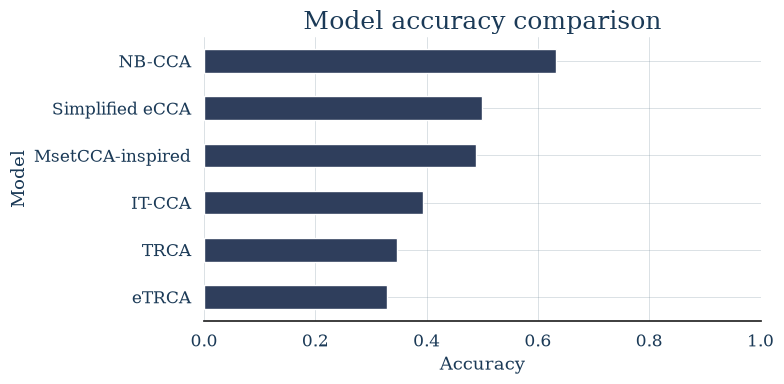

In [64]:
plot_accuracy_bar(advanced_summary_df)


In [65]:
advanced_per_class_comparison = pd.DataFrame({
    "NB_CCA": per_class_accuracy(nbcca_df_advanced),
    "IT_CCA": per_class_accuracy(itcca_df_advanced),
    "eCCA_simplified": per_class_accuracy(ecca_df_advanced),
    "MsetCCA_inspired": per_class_accuracy(msetcca_df_advanced),
    "TRCA": per_class_accuracy(trca_df_advanced),
    "eTRCA": per_class_accuracy(etrca_df_advanced),
})

advanced_per_class_comparison


,NB_CCA,IT_CCA,eCCA_simplified,MsetCCA_inspired,TRCA,eTRCA
true_label,,,,,,
8.57,0.590909,0.442424,0.366667,0.321212,0.309091,0.351515
10.00,0.676364,0.374545,0.912727,0.629091,0.356364,0.334545
12.00,0.636364,0.352727,0.243636,0.549091,0.381818,0.294545


## 13.10 Advanced-method interpretation

These methods answer a different question than calibration-free CCA/FBCCA. CCA and FBCCA ask: *how far can we get using predefined sine/cosine references?* Template-based methods ask: *how much can we improve if training/calibration trials are available?*

When interpreting results, compare:

- calibration-free methods: CCA, FBCCA, NB-CCA,
- template/calibration methods: IT-CCA, simplified eCCA, MsetCCA-inspired, TRCA, eTRCA.

If TRCA/eTRCA or template-based methods clearly outperform CCA/FBCCA, it supports the conclusion that a practical SSVEP control system should include user-specific calibration.


> **Historical diagnostic only.** Subject-mixed results below are intentionally retained to document the earlier validation mistake. They must not enter the final v5 benchmark.

## 13.9b Subject-mixed (v3) vs. subject-dependent (fixed) comparison

The table and plot below put the original (buggy, subject-mixed) results next to the
subject-dependent (fixed) results for every calibrated method, plus the new FB-eTRCA
method, so the effect of the CV fix is visible directly rather than only in prose.
Calibration-free methods (CCA, FBCCA, NB-CCA) are included as a reference line — they are
identical to before, since they never depended on the CV protocol.


In [66]:
fix_comparison_results = [
    {"model": "IT-CCA (v3, subject-mixed)", "df": itcca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "buggy CV"},
    {"model": "IT-CCA (fixed, subject-dependent)", "df": itcca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "fixed CV"},
    {"model": "Simplified eCCA (v3, subject-mixed)", "df": ecca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "buggy CV"},
    {"model": "Simplified eCCA (fixed, subject-dependent)", "df": ecca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "fixed CV"},
    {"model": "MsetCCA-inspired (v3, subject-mixed)", "df": msetcca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "buggy CV"},
    {"model": "MsetCCA-inspired (fixed, subject-dependent)", "df": msetcca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "fixed CV"},
    {"model": "TRCA (v3, subject-mixed)", "df": trca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "buggy CV"},
    {"model": "TRCA (fixed, subject-dependent)", "df": trca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "fixed CV"},
    {"model": "eTRCA (v3, subject-mixed)", "df": etrca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "buggy CV"},
    {"model": "eTRCA (fixed, subject-dependent)", "df": etrca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "fixed CV"},
    {"model": "FB-eTRCA (new, subject-dependent)", "df": fbtrca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "new method, fixed CV"},
    {"model": "NB-CCA (reference, calibration-free)", "df": nbcca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "unaffected by CV fix"},
]

fix_comparison_df = summarize_model_results(fix_comparison_results)
fix_comparison_df


,model,n_classes,chance_level,accuracy,balanced_accuracy,gain_over_chance,comment
11,"NB-CCA (reference, calibration-free)",3,0.333333,0.631818,0.634545,0.298485,unaffected by CV fix
3,"Simplified eCCA (fixed, subject-dependent)",3,0.333333,0.540909,0.544242,0.207576,fixed CV
2,"Simplified eCCA (v3, subject-mixed)",3,0.333333,0.498864,0.507677,0.165530,buggy CV
4,"MsetCCA-inspired (v3, subject-mixed)",3,0.333333,0.488636,0.499798,0.155303,buggy CV
5,"MsetCCA-inspired (fixed, subject-dependent)",3,0.333333,0.432955,0.437778,0.099621,fixed CV
0,"IT-CCA (v3, subject-mixed)",3,0.333333,0.393182,0.389899,0.059848,buggy CV
1,"IT-CCA (fixed, subject-dependent)",3,0.333333,0.375000,0.375556,0.041667,fixed CV
9,"eTRCA (fixed, subject-dependent)",3,0.333333,0.351136,0.352525,0.017803,fixed CV
6,"TRCA (v3, subject-mixed)",3,0.333333,0.346591,0.349091,0.013258,buggy CV
10,"FB-eTRCA (new, subject-dependent)",3,0.333333,0.345455,0.347273,0.012121,"new method, fixed CV"


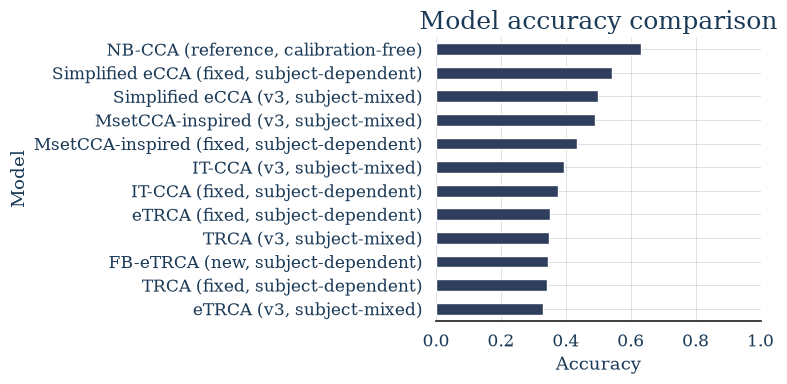

In [67]:
plot_accuracy_bar(fix_comparison_df)


### 13.9b Interpretation

If the fix is working as expected, every "fixed, subject-dependent" row should score
noticeably higher than its "v3, subject-mixed" counterpart, and TRCA/eTRCA in particular
should move from ~chance level to clearly above the calibration-free methods (CCA, FBCCA,
NB-CCA), since they are the methods most reliant on genuine within-subject reproducibility.
FB-eTRCA is the best candidate for the highest overall accuracy, since it combines the two
ingredients (filter-bank decomposition, subject-specific spatial filters) that helped the
most individually.

If subject-dependent accuracy is still not close to the target, the next places to look are:

- the trial-length note in section 5.3b (longer windows generally help TRCA-family methods
  more than CCA-family methods, because more samples means a better-conditioned covariance
  estimate for the spatial filter),
- the subject-wise breakdown in section 16 (a few consistently weak subjects can drag down
  the mean; consider reporting median-subject accuracy alongside the pooled mean, and
  investigating whether those subjects have noisy/artifact-heavy recordings),
- using more than the 4 posterior channels for TRCA/FB-eTRCA specifically, since these
  methods learn their own spatial weighting and can benefit from extra (even noisier)
  channels in a way that fixed sine/cosine CCA cannot.


# 14. Frequency selection analysis

## 14.1 Motivation

Class-wise accuracy may reveal that some stimulation frequencies are much easier to classify than others. In a practical SSVEP control system, weak frequencies should not automatically be assigned to important commands.

## 14.2 5-class setup

The 5-class setup uses all available target frequencies:

```text
6.66, 7.50, 8.57, 10.00, 12.00 Hz
```

## 14.3 4-class setup without 6.66 Hz

In [68]:
TARGET_FREQS_4 = [7.50, 8.57, 10.00, 12.00]

X_4, labels_4, metadata_4, X_posterior_4 = make_frequency_subset(
    X=X,
    labels_float=labels_float,
    metadata=metadata,
    selected_target_freqs=TARGET_FREQS_4,
    channel_indices=POSTERIOR_CHANNEL_INDICES,
)

fbcca_df_4 = fbcca_predict(
    trials=X_posterior_4,
    true_labels=labels_4,
    target_freqs=TARGET_FREQS_4,
    fs=FS,
    filter_bands=DEFAULT_FBCCA_BANDS,
    n_harmonics=3,
    metadata=metadata_4,
)

print_metrics(fbcca_df_4, "FBCCA 4-class without 6.66 Hz")
print("Per-class accuracy:")
print(per_class_accuracy(fbcca_df_4))

FBCCA 4-class without 6.66 Hz accuracy: 61.47%
FBCCA 4-class without 6.66 Hz balanced accuracy: 61.76%

              precision    recall  f1-score   support

       10.00      0.492     0.785     0.605       275
       12.00      0.582     0.669     0.623       275
        7.50      0.829     0.458     0.590       275
        8.57      0.742     0.558     0.637       330

    accuracy                          0.615      1155
   macro avg      0.661     0.618     0.614      1155
weighted avg      0.665     0.615     0.615      1155

Per-class accuracy:
true_label
7.50     0.458182
8.57     0.557576
10.00    0.785455
12.00    0.669091
Name: correct, dtype: float64


## 14.4 3-class setup

In [69]:
TARGET_FREQS_3 = [8.57, 10.00, 12.00]

X_3, labels_3, metadata_3, X_posterior_3 = make_frequency_subset(
    X=X,
    labels_float=labels_float,
    metadata=metadata,
    selected_target_freqs=TARGET_FREQS_3,
    channel_indices=POSTERIOR_CHANNEL_INDICES,
)

fbcca_df_3 = fbcca_predict(
    trials=X_posterior_3,
    true_labels=labels_3,
    target_freqs=TARGET_FREQS_3,
    fs=FS,
    filter_bands=DEFAULT_FBCCA_BANDS,
    n_harmonics=3,
    metadata=metadata_3,
)

print_metrics(fbcca_df_3, "FBCCA 3-class")
print("Per-class accuracy:")
print(per_class_accuracy(fbcca_df_3))

FBCCA 3-class accuracy: 67.50%
FBCCA 3-class balanced accuracy: 68.24%

              precision    recall  f1-score   support

       10.00      0.597     0.807     0.686       275
       12.00      0.671     0.676     0.674       275
        8.57      0.805     0.564     0.663       330

    accuracy                          0.675       880
   macro avg      0.691     0.682     0.674       880
weighted avg      0.698     0.675     0.674       880

Per-class accuracy:
true_label
8.57     0.563636
10.00    0.807273
12.00    0.676364
Name: correct, dtype: float64


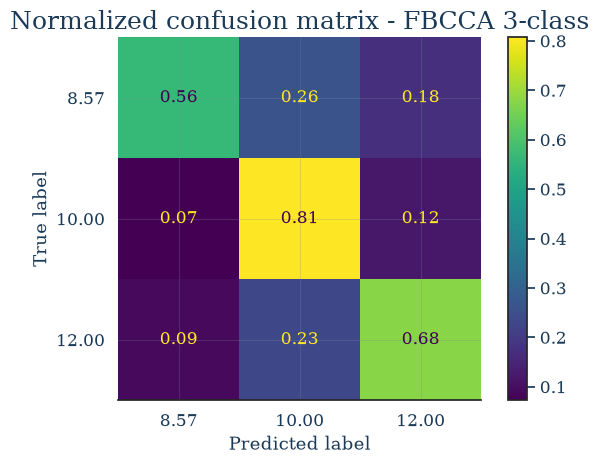

In [70]:
plot_confusion(
    fbcca_df_3,
    labels_order=TARGET_FREQS_3,
    title="Normalized confusion matrix - FBCCA 3-class",
)

## 14.5 Comparison table

In [71]:
frequency_selection_summary = summarize_model_results([
    {
        "model": "FBCCA 5-class",
        "df": fbcca_df_5,
        "n_classes": 5,
        "comment": "all available frequencies",
    },
    {
        "model": "FBCCA 4-class",
        "df": fbcca_df_4,
        "n_classes": 4,
        "comment": "without 6.66 Hz",
    },
    {
        "model": "FBCCA 3-class",
        "df": fbcca_df_3,
        "n_classes": 3,
        "comment": "8.57, 10.00, 12.00 Hz",
    },
])

frequency_selection_summary

,model,n_classes,chance_level,accuracy,balanced_accuracy,gain_over_chance,comment
2,FBCCA 3-class,3,0.333333,0.675000,0.682424,0.341667,"8.57, 10.00, 12.00 Hz"
1,FBCCA 4-class,4,0.250000,0.614719,0.617576,0.364719,without 6.66 Hz
0,FBCCA 5-class,5,0.200000,0.556364,0.551091,0.356364,all available frequencies


## 14.6 Interpretation

If the reduced-class setups improve performance, this supports the conclusion that frequency selection is a critical design step. In an applied BCI system, it may be better to use fewer but more separable commands than to force all available stimulation frequencies into the interface.

# 15. Model comparison

## 15.1 Summary table

In [72]:
base_model_results = [
    {
        "model": "SNR baseline 5-class",
        "df": snr_df_5,
        "n_classes": 5,
        "comment": "simple spectral baseline",
    },
    {
        "model": "CCA 5-class",
        "df": cca_df_5,
        "n_classes": 5,
        "comment": "standard CCA",
    },
    {
        "model": "FBCCA 5-class",
        "df": fbcca_df_5,
        "n_classes": 5,
        "comment": "filter-bank CCA",
    },
    {
        "model": "FBCCA 4-class",
        "df": fbcca_df_4,
        "n_classes": 4,
        "comment": "without 6.66 Hz",
    },
    {
        "model": "FBCCA 3-class",
        "df": fbcca_df_3,
        "n_classes": 3,
        "comment": "selected frequencies",
    },
]

# Add advanced-method results if Section 13 has been executed.
if "advanced_model_results" in globals():
    model_summary_df = summarize_model_results(base_model_results + advanced_model_results)
else:
    model_summary_df = summarize_model_results(base_model_results)

model_summary_df


,model,n_classes,chance_level,accuracy,balanced_accuracy,gain_over_chance,comment
4,FBCCA 3-class,3,0.333333,0.675000,0.682424,0.341667,selected frequencies
5,NB-CCA,3,0.333333,0.631818,0.634545,0.298485,"narrow-band, no templates"
3,FBCCA 4-class,4,0.250000,0.614719,0.617576,0.364719,without 6.66 Hz
2,FBCCA 5-class,5,0.200000,0.556364,0.551091,0.356364,filter-bank CCA
1,CCA 5-class,5,0.200000,0.549818,0.543636,0.349818,standard CCA
7,Simplified eCCA,3,0.333333,0.498864,0.507677,0.165530,"reference + template score, CV"
8,MsetCCA-inspired,3,0.333333,0.488636,0.499798,0.155303,"learned class references, CV"
6,IT-CCA,3,0.333333,0.393182,0.389899,0.059848,"individual templates, CV"
9,TRCA,3,0.333333,0.346591,0.349091,0.013258,"class-specific spatial filters, CV"
0,SNR baseline 5-class,5,0.200000,0.335273,0.326424,0.135273,simple spectral baseline


### 15.1b Including the subject-dependent fixed methods

The cell below extends the section 15.1 comparison with the subject-dependent
(fixed) calibrated methods and FB-eTRCA from section 13, if they were run.


In [73]:
fixed_method_results = [
    {"model": "IT-CCA (subject-dependent)", "df": itcca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "individual templates, subject CV"},
    {"model": "Simplified eCCA (subject-dependent)", "df": ecca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "reference + template, subject CV"},
    {"model": "MsetCCA-inspired (subject-dependent)", "df": msetcca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "learned references, subject CV"},
    {"model": "TRCA (subject-dependent)", "df": trca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "spatial filters, subject CV"},
    {"model": "eTRCA (subject-dependent)", "df": etrca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "ensemble filters, subject CV"},
    {"model": "FB-eTRCA (subject-dependent)", "df": fbtrca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "filter-bank + TRCA, subject CV"},
]

if "advanced_model_results" in globals():
    all_names = {r["model"] for r in base_model_results + advanced_model_results}
else:
    all_names = {r["model"] for r in base_model_results}

model_summary_df_full = summarize_model_results(
    base_model_results
    + (advanced_model_results if "advanced_model_results" in globals() else [])
    + fixed_method_results
)
model_summary_df_full


,model,n_classes,chance_level,accuracy,balanced_accuracy,gain_over_chance,comment
4,FBCCA 3-class,3,0.333333,0.675000,0.682424,0.341667,selected frequencies
5,NB-CCA,3,0.333333,0.631818,0.634545,0.298485,"narrow-band, no templates"
3,FBCCA 4-class,4,0.250000,0.614719,0.617576,0.364719,without 6.66 Hz
2,FBCCA 5-class,5,0.200000,0.556364,0.551091,0.356364,filter-bank CCA
1,CCA 5-class,5,0.200000,0.549818,0.543636,0.349818,standard CCA
12,Simplified eCCA (subject-dependent),3,0.333333,0.540909,0.544242,0.207576,"reference + template, subject CV"
7,Simplified eCCA,3,0.333333,0.498864,0.507677,0.165530,"reference + template score, CV"
8,MsetCCA-inspired,3,0.333333,0.488636,0.499798,0.155303,"learned class references, CV"
13,MsetCCA-inspired (subject-dependent),3,0.333333,0.432955,0.437778,0.099621,"learned references, subject CV"
6,IT-CCA,3,0.333333,0.393182,0.389899,0.059848,"individual templates, CV"


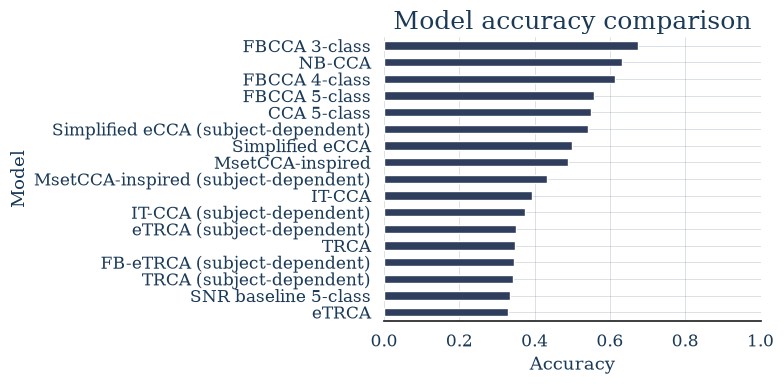

In [74]:
plot_accuracy_bar(model_summary_df_full)


## 15.2 Accuracy bar plot

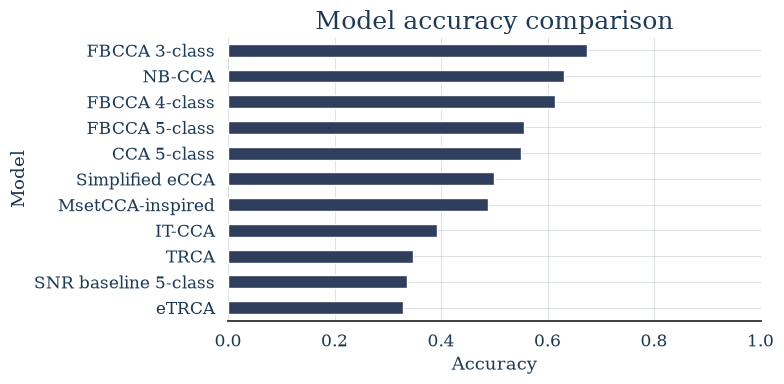

In [75]:
plot_accuracy_bar(model_summary_df)

## 15.3 Per-class comparison

In [76]:
per_class_comparison = pd.DataFrame({
    "SNR_5_class": per_class_accuracy(snr_df_5),
    "CCA_5_class": per_class_accuracy(cca_df_5),
    "FBCCA_5_class": per_class_accuracy(fbcca_df_5),
})

per_class_comparison

,SNR_5_class,CCA_5_class,FBCCA_5_class
true_label,,,
6.66,0.154545,0.400000,0.404545
7.50,0.298182,0.450909,0.450909
8.57,0.375758,0.554545,0.536364
10.00,0.429091,0.741818,0.716364
12.00,0.374545,0.570909,0.647273


## 15.4 Practical interpretation

The practical interpretation should focus on whether the classification accuracy is high enough for stable control. Frequencies with consistently weak per-class accuracy should be treated cautiously or excluded from the command set.

# 16. Subject-wise analysis

## 16.1 Why subject-wise analysis matters

EEG and SSVEP responses vary strongly between subjects. A global accuracy value can hide high performance for some participants and poor performance for others. Therefore, subject-wise accuracy is important for evaluating whether user-specific calibration may be required.

## 16.2 Add subject metadata

The prediction functions above attach subject/session/run metadata whenever those columns are available in the MOABB metadata table.

## 16.3 Accuracy per subject

subject
1     0.752
2     0.920
3     0.272
4     0.528
5     0.184
6     0.480
7     0.408
8     0.304
9     0.768
10    0.760
11    0.744
Name: correct, dtype: float64


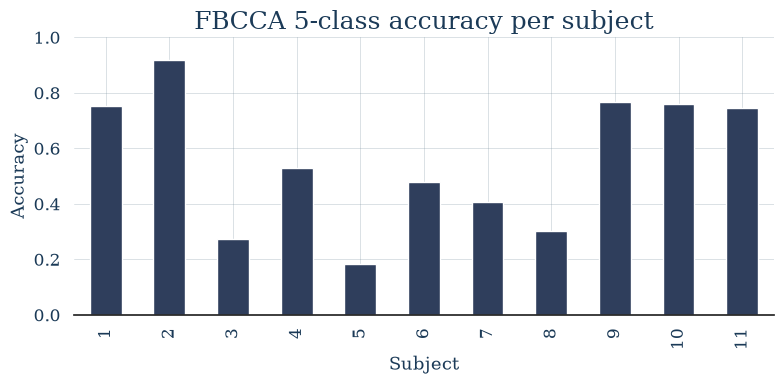

In [77]:
if "subject" in fbcca_df_5.columns:
    subject_accuracy_fbcca = (
        fbcca_df_5
        .groupby("subject")["correct"]
        .mean()
        .sort_index()
    )
    print(subject_accuracy_fbcca)

    ax = subject_accuracy_fbcca.plot(kind="bar", figsize=(8, 4))
    ax.set_xlabel("Subject")
    ax.set_ylabel("Accuracy")
    ax.set_title("FBCCA 5-class accuracy per subject")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Subject metadata not available in prediction results.")

## 16.4 Interpretation

Large differences between subjects would suggest that a real system should include subject-specific calibration and possibly subject-specific frequency selection.

# 17. Error analysis

## 17.1 Confusion matrix analysis

The confusion matrix should be used to identify which target frequencies are confused with each other.

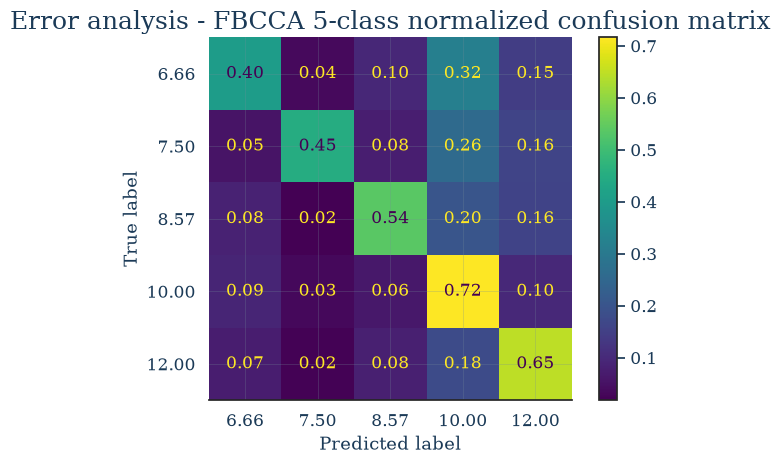

In [78]:
plot_confusion(
    fbcca_df_5,
    labels_order=TARGET_FREQS_ALL,
    title="Error analysis - FBCCA 5-class normalized confusion matrix",
)

## 17.2 Weak frequencies

The weakest frequencies can be identified from per-class accuracy and confusion matrices. In this dataset, low-frequency classes such as 6.66 Hz and 7.50 Hz may require special attention.

## 17.3 Possible causes

Possible reasons for weaker classes include:

- weaker SSVEP response for some stimulation frequencies,
- overlap with background EEG activity,
- weaker or noisier harmonic structure,
- lower number of trials for some labels,
- individual subject variability,
- limited channel count.

## 17.4 Consequences for control system

Weak frequencies should not be assigned to critical real-time control commands unless they are validated with additional data and subject-specific calibration.

# 18. Practical BCI control system discussion

## 18.1 Proposed command mapping

A possible conservative command mapping could use the most separable frequencies first. For example:

```text
10.00 Hz -> primary command
12.00 Hz -> secondary command
8.57 Hz  -> third command
```

This mapping should be treated as provisional and should be validated on real hardware.

## 18.2 Recommended number of commands

If the 3-class setup performs much better than the 5-class setup, a smaller command set may be more reliable for an early prototype.

## 18.3 Safety layer

A real control system should include safety mechanisms:

- no-command threshold,
- low-confidence rejection,
- majority voting across consecutive windows,
- confirmation command for critical actions,
- emergency stop or manual override.

## 18.4 Real-time considerations

Real-time SSVEP classification requires a trade-off between speed and accuracy. Longer windows usually improve frequency resolution and classification stability, but increase command latency.

# 19. Future work

The advanced methods above are implemented as transparent notebook-level versions. Further work should focus on:

## 19.1 Parameter tuning

- systematic grid search for CCA/FBCCA bands,
- harmonic selection,
- narrow-band width tuning,
- trial trimming and window length selection,
- channel subset selection.

## 19.2 Validation protocol

- subject-wise train/test splits,
- leave-one-subject-out testing,
- within-subject calibration vs cross-subject generalization,
- repeated cross-validation with confidence intervals.

## 19.3 Reference implementations

Compare the custom educational implementations with library implementations from MOABB and SSVEP Analysis Toolbox, especially for TRCA, eTRCA and MsetCCA.

## 19.4 Real hardware validation

The final system should be validated with the intended LED/monitor stimulation setup, online predictions, no-command rejection and safety confirmation logic.


# 20. Final conclusions from the saved v4 run

## 20.1 What is already supported by the saved outputs

The saved v4 outputs support three robust observations:

1. A simple local-SNR classifier is a useful baseline but is clearly weaker than multichannel CCA-family methods.
2. Standard CCA provides the largest jump over the spectral baseline, whereas the tested FBCCA configuration adds only a modest improvement in the 5-class problem.
3. The exploratory 3-class subset `8.57 / 10.00 / 12.00 Hz` is more separable in the current pipeline than the full 5-class configuration, but this subset was selected after inspecting the dataset and therefore must be described as an **exploratory design result**, not an unbiased final benchmark.

The saved subject-wise analysis also shows strong inter-subject variability. Therefore, pooled trial accuracy alone is not sufficient to describe expected BCI performance.

## 20.2 Important unresolved issue from v4

The v4 subject-dependent fix removed cross-subject template mixing, but TRCA/eTRCA remained close to chance. This means the earlier subject-mixing bug was not the only issue. In v5, these algorithms are re-implemented with reference-like target scoring and evaluated again using subject-dependent folds.

## 20.3 v5 conclusion policy

Section 21 performs the robustness and corrected-evaluation analysis. New conclusions should be based on the outputs of Section 21 rather than manually copied numbers. In particular, the v5 interpretation should report:

- pooled accuracy and balanced accuracy,
- mean / median / standard deviation across subjects,
- 95% bootstrap confidence interval across subjects,
- class count and chance level,
- whether a configuration was pre-specified or selected exploratorily.


## 20.4 Historical note: subject-dependent calibration fix (v4)

The v3 notebook mixed subjects inside the cross-validation used by calibrated template/spatial-filter methods. v4 correctly replaced that protocol with within-subject folds. The saved v4 outputs show, however, that this protocol correction **did not by itself rescue TRCA/eTRCA performance**: the TRCA-family methods remained close to the 3-class chance level.

Therefore, v5 does not attribute the weak v4 TRCA result only to subject mixing. Section 21 separately audits the TRCA target-scoring equations, preprocessing choices, channel montage and subject-level behavior. The old subject-mixed outputs remain in the notebook only as a reproducibility / methodology example and are excluded from the v5 final benchmark.


# 21. Accuracy optimization and robustness analysis (v5)

This section is the **current analysis layer**. Sections 1–20 remain available as the historical EDA/baseline and preserve their saved outputs.

The goals here are:

- improve scientific correctness before optimizing accuracy,
- make subject variability explicit,
- separate deterministic preprocessing from trainable methods,
- validate TRCA/eTRCA scoring against the equations used in the original TRCA framework,
- perform only small, hypothesis-driven channel / onset / FBCCA studies,
- avoid presenting exploratory frequency selection or hyperparameter selection as an unbiased final benchmark.

Unless stated otherwise, the primary 3-class design study uses `8.57 / 10.00 / 12.00 Hz` because that subset was already selected in the exploratory v4 analysis. This must remain clearly labeled as **exploratory selection**.


## 21.1 Preprocessing audit and v5 experiment configuration

### Documented source preprocessing

Current MOABB metadata for MAMEM3 reports a 14-channel, 128 Hz representation with **CAR reference**, **5–48 Hz band-pass**, **50 Hz notch** and dataset-level artifact processing (AMUSE / ICA). The original recordings contain 5-second flicker windows, while the representation loaded in this notebook contains approximately 3-second epochs.

References:

- MOABB MAMEM3 documentation: https://moabb.neurotechx.com/docs/generated/moabb.datasets.MAMEM3.html
- MOABB preprocessing overview: https://moabb.neurotechx.com/docs/auto_examples/advanced_examples/plot_pre_processing_steps.html

### Consequence for v5

A further broad 5–45 Hz filter is **not treated as automatically necessary**. Calibration-free CCA and base TRCA/eTRCA are therefore evaluated first on the array returned by MOABB (after channel selection / optional onset trimming). Filter-bank methods still apply their sub-band filters because this decomposition is part of the classifier itself.

This is a methodological choice, not a claim that an additional broad band-pass can never help. If it is tested, it should be reported as an explicit preprocessing variant rather than silently stacked on top of the source preprocessing.


In [79]:
# v5 experiment configuration — deliberately small and explicit.
V5_TARGET_FREQS_3 = [8.57, 10.00, 12.00]
V5_TARGET_FREQS_4 = [7.50, 8.57, 10.00, 12.00]
V5_TARGET_FREQS_5 = [6.66, 7.50, 8.57, 10.00, 12.00]

V5_CHANNEL_SETS = {
    "O1_O2": [EPOC_CHANNELS.index("O1"), EPOC_CHANNELS.index("O2")],
    "posterior_4": [EPOC_CHANNELS.index(ch) for ch in ["O1", "O2", "P7", "P8"]],
    "all_14": list(range(len(EPOC_CHANNELS))),
}

# Current notebook filter bank and a literature-inspired, Nyquist/source-band-adapted alternative.
V5_FBANDS_CURRENT = [(5, 45), (10, 45), (15, 45)]
V5_FBANDS_8HZ_ADAPTED = [(5, 45), (14, 45), (22, 45)]

V5_TRIM_OPTIONS_SEC = [0.0, 0.25, 0.50]
V5_N_SPLITS = 5
V5_BOOTSTRAP_ITERATIONS = 5000
V5_QC_ROBUST_Z_THRESHOLD = 5.0

# Expensive studies can be disabled independently while debugging the notebook.
V5_RUN_CHANNEL_STUDY = True
V5_RUN_TRIM_STUDY = True
V5_RUN_FBCCA_GRID = True

# Explicit label mapping for reporting. The existing notebook still stores physical
# frequencies as labels for backwards compatibility.
V5_CLASS_TO_FREQ = {idx: freq for idx, freq in enumerate(V5_TARGET_FREQS_3)}
V5_FREQ_TO_CLASS = {freq: idx for idx, freq in V5_CLASS_TO_FREQ.items()}

print("v5 3-class frequencies:", V5_TARGET_FREQS_3)
print("v5 channel sets:", {k: [EPOC_CHANNELS[i] for i in v] for k, v in V5_CHANNEL_SETS.items()})


v5 3-class frequencies: [8.57, 10.0, 12.0]
v5 channel sets: {'O1_O2': ['O1', 'O2'], 'posterior_4': ['O1', 'O2', 'P7', 'P8'], 'all_14': ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']}


In [80]:
def v5_validate_trials(
    trials: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame | None = None,
) -> None:
    """Basic shape/finite-value assertions used before v5 experiments."""
    trials = np.asarray(trials)
    labels = np.asarray(labels)

    if trials.ndim != 3:
        raise ValueError(f"Expected trials shape (n_trials, n_channels, n_samples), got {trials.shape}.")
    if trials.shape[0] != len(labels):
        raise ValueError("Number of trials and labels does not match.")
    if metadata is not None and len(metadata) != len(labels):
        raise ValueError("Metadata length does not match labels.")
    if not np.all(np.isfinite(trials)):
        raise ValueError("Non-finite values found in EEG tensor.")


def v5_prepare_trials(
    trials: np.ndarray,
    fs: int,
    channel_indices: list[int] | None = None,
    trim_start_sec: float = 0.0,
    broad_filter_band: tuple[float, float] | None = None,
    filter_order: int = 4,
) -> np.ndarray:
    """Deterministic v5 preprocessing: channel selection -> trim -> optional broad filter.

    The default broad_filter_band=None is intentional because the current MAMEM3 metadata
    already describes source-level 5–48 Hz preprocessing. Filter-bank classifiers apply
    their own sub-band decomposition separately.
    """
    X = np.asarray(trials, dtype=float)

    if channel_indices is not None:
        X = X[:, channel_indices, :]

    X = trim_trials(X, fs=fs, trim_start_sec=trim_start_sec)

    if broad_filter_band is not None:
        lowcut, highcut = broad_filter_band
        X = filter_eeg_trials(
            X,
            lowcut=lowcut,
            highcut=highcut,
            fs=fs,
            order=filter_order,
            filter_type="butter",
        )

    return X


def v5_make_subset(
    trials: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame,
    target_freqs: list[float],
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Selects a frequency subset without changing channel structure."""
    labels_float_local = np.asarray(labels, dtype=float)
    mask = np.isin(labels_float_local, np.asarray(target_freqs, dtype=float))
    X_sub = np.asarray(trials)[mask]
    y_sub = labels_float_local[mask]
    meta_sub = metadata.loc[mask].reset_index(drop=True)
    v5_validate_trials(X_sub, y_sub, meta_sub)
    return X_sub, y_sub, meta_sub


# Core v5 subsets from the array returned by MOABB.
X_v5_3_all, y_v5_3, meta_v5_3 = v5_make_subset(X, labels_float, metadata, V5_TARGET_FREQS_3)
X_v5_4_all, y_v5_4, meta_v5_4 = v5_make_subset(X, labels_float, metadata, V5_TARGET_FREQS_4)
X_v5_5_all, y_v5_5, meta_v5_5 = v5_make_subset(X, labels_float, metadata, V5_TARGET_FREQS_5)

X_v5_3_post = v5_prepare_trials(X_v5_3_all, FS, V5_CHANNEL_SETS["posterior_4"])
X_v5_4_post = v5_prepare_trials(X_v5_4_all, FS, V5_CHANNEL_SETS["posterior_4"])
X_v5_5_post = v5_prepare_trials(X_v5_5_all, FS, V5_CHANNEL_SETS["posterior_4"])

print("X_v5_3_post:", X_v5_3_post.shape)


X_v5_3_post: (880, 4, 385)


In [81]:
# Compact audit table: source-level processing vs notebook-level operations.
preprocessing_audit_v5 = pd.DataFrame([
    {
        "stage": "MAMEM3 / MOABB metadata",
        "operation": "CAR reference",
        "v5_action": "Do not apply a second CAR by default",
    },
    {
        "stage": "MAMEM3 / MOABB metadata",
        "operation": "5–48 Hz band-pass + 50 Hz notch",
        "v5_action": "Base CCA/TRCA start without another broad band-pass",
    },
    {
        "stage": "MAMEM3 / MOABB metadata",
        "operation": "artifact processing reported in dataset metadata",
        "v5_action": "QC is diagnostic; no accuracy-driven trial rejection",
    },
    {
        "stage": "v5 filter-bank methods",
        "operation": "sub-band filtering",
        "v5_action": "Keep: this is part of FBCCA / FB-TRCA",
    },
    {
        "stage": "v5 optional experiment",
        "operation": "additional broad band-pass",
        "v5_action": "Only as an explicitly labeled variant",
    },
])
preprocessing_audit_v5


,stage,operation,v5_action
0,MAMEM3 / MOABB metadata,CAR reference,Do not apply a second CAR by default
1,MAMEM3 / MOABB metadata,5–48 Hz band-pass + 50 Hz notch,Base CCA/TRCA start without another broad band...
2,MAMEM3 / MOABB metadata,artifact processing reported in dataset metadata,QC is diagnostic; no accuracy-driven trial rej...
3,v5 filter-bank methods,sub-band filtering,Keep: this is part of FBCCA / FB-TRCA
4,v5 optional experiment,additional broad band-pass,Only as an explicitly labeled variant


## 21.2 Corrected/reference-like TRCA and eTRCA

The v4 TRCA implementation learned a plausible spatial filter but used `rho ** 2` directly as the **single-band base TRCA** class score. In the original TRCA formulation, the single-band class score is the Pearson correlation between the spatially filtered test trial and averaged class template, and the target is selected by the maximum correlation.

For ensemble TRCA, class-specific filters are stacked into an ensemble matrix `W`, and the test/template matrices are jointly projected. The original method uses a **2-D correlation** between those projected matrices. Here this is implemented by vectorizing the two equally shaped projected matrices before Pearson correlation, which is equivalent to correlating their concatenated entries.

For filter-bank fusion, the original TRCA framework uses:

\[
\rho_n = \sum_m a(m)\left(r_n^{(m)}\right)^2,
\qquad a(m)=m^{-1.25}+0.25.
\]

Therefore, squaring is retained at the **filter-bank fusion stage**, not at the base single-band TRCA decision stage.

Primary reference: Nakanishi et al., *Enhancing Detection of SSVEPs for a High-Speed Brain Speller Using Task-Related Component Analysis*.


In [82]:
def v5_learn_trca_filter(
    class_trials: np.ndarray,
    reg: float = 1e-6,
) -> np.ndarray:
    """Reference-like TRCA spatial filter for one stimulus class.

    S: summed inter-trial cross-covariance.
    Q: covariance-like matrix of concatenated centered training trials.
    The dominant generalized eigenvector maximizes w.T @ S @ w / (w.T @ Q @ w).
    """
    trials = np.asarray(class_trials, dtype=float)
    if trials.ndim != 3 or trials.shape[0] < 2:
        raise ValueError("TRCA requires at least two training trials for a class.")

    # Remove per-channel temporal mean in every trial before covariance construction.
    trials_c = trials - trials.mean(axis=2, keepdims=True)
    n_trials, n_channels, _ = trials_c.shape

    S = np.zeros((n_channels, n_channels), dtype=float)
    for i in range(n_trials - 1):
        Xi = trials_c[i]
        for j in range(i + 1, n_trials):
            Xj = trials_c[j]
            # Add both directions explicitly to keep S symmetric.
            S += Xi @ Xj.T + Xj @ Xi.T

    concatenated = np.concatenate([trials_c[i] for i in range(n_trials)], axis=1)
    Q = concatenated @ concatenated.T

    # Scale-aware ridge regularization for numerical stability only.
    scale = np.trace(Q) / max(n_channels, 1)
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    Q_reg = Q + reg * scale * np.eye(n_channels)

    S = 0.5 * (S + S.T)
    Q_reg = 0.5 * (Q_reg + Q_reg.T)

    eigvals, eigvecs = eigh(S, Q_reg)
    w = np.real(eigvecs[:, int(np.argmax(np.real(eigvals)))])
    norm = np.linalg.norm(w)
    if norm == 0:
        raise ValueError("Degenerate TRCA spatial filter.")
    return w / norm


def v5_train_trca_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    target_freqs: list[float],
) -> tuple[dict[float, np.ndarray], dict[float, np.ndarray]]:
    """Learns averaged class templates and one TRCA filter per class."""
    templates = build_class_templates(X_train, y_train, target_freqs)
    y_train = np.asarray(y_train, dtype=float)
    filters = {}

    for freq in target_freqs:
        f = float(freq)
        class_trials = X_train[np.isclose(y_train, f, atol=0.01)]
        filters[f] = v5_learn_trca_filter(class_trials)

    return templates, filters


def v5_trca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Single-band TRCA using signed Pearson correlation for target scoring."""
    del fs  # data are already prepared before entering this classifier
    templates, filters = v5_train_trca_model(X_train, y_train, target_freqs)
    rows = []

    for trial_idx, trial in enumerate(X_test):
        scores = {}
        for freq in target_freqs:
            f = float(freq)
            w = filters[f]
            rho = safe_corrcoef(w @ trial, w @ templates[f])
            scores[f] = rho

        pred = max(scores, key=scores.get)
        row = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(pred),
            "trca_score": float(scores[pred]),
        }
        for f, score in scores.items():
            row[f"TRCA_{f:.2f}"] = float(score)
        rows.append(add_metadata_to_result(row, metadata_test, trial_idx))

    df = pd.DataFrame(rows)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


def v5_etrca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Reference-like ensemble TRCA using 2-D correlation after ensemble projection."""
    del fs
    templates, filters = v5_train_trca_model(X_train, y_train, target_freqs)
    W = np.column_stack([filters[float(f)] for f in target_freqs])  # channels x classes
    rows = []

    for trial_idx, trial in enumerate(X_test):
        projected_test = trial.T @ W  # time x ensemble-components
        scores = {}

        for freq in target_freqs:
            f = float(freq)
            projected_template = templates[f].T @ W
            # 2-D correlation: concatenate all corresponding projected entries.
            rho_2d = safe_corrcoef(projected_test.ravel(), projected_template.ravel())
            scores[f] = rho_2d

        pred = max(scores, key=scores.get)
        row = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(pred),
            "etrca_score": float(scores[pred]),
        }
        for f, score in scores.items():
            row[f"eTRCA_{f:.2f}"] = float(score)
        rows.append(add_metadata_to_result(row, metadata_test, trial_idx))

    df = pd.DataFrame(rows)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [83]:
def v5_fbtrca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_bands: list[tuple[float, float]] | None = None,
    filter_order: int = 4,
    ensemble: bool = True,
    weights: np.ndarray | None = None,
) -> pd.DataFrame:
    """Filter-bank TRCA/eTRCA with standard weighted squared-correlation fusion.

    Each sub-band trains its own TRCA model. The base sub-band score is a signed
    correlation (TRCA or 2-D eTRCA). Only the final filter-bank fusion squares it.
    """
    if filter_bands is None:
        filter_bands = V5_FBANDS_CURRENT

    if weights is None:
        weights = np.array([
            (m + 1) ** (-1.25) + 0.25
            for m in range(len(filter_bands))
        ], dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)

    if len(weights) != len(filter_bands):
        raise ValueError("weights length must match filter_bands length.")

    band_models = []
    for lowcut, highcut in filter_bands:
        Xtr_b = filter_eeg_trials(
            X_train, lowcut=lowcut, highcut=highcut, fs=fs,
            order=filter_order, filter_type="butter",
        )
        Xte_b = filter_eeg_trials(
            X_test, lowcut=lowcut, highcut=highcut, fs=fs,
            order=filter_order, filter_type="butter",
        )
        templates, filters = v5_train_trca_model(Xtr_b, y_train, target_freqs)
        W = np.column_stack([filters[float(f)] for f in target_freqs])
        band_models.append((Xte_b, templates, filters, W))

    rows = []
    for trial_idx in range(len(X_test)):
        fused_scores = {float(f): 0.0 for f in target_freqs}

        for band_idx, (Xte_b, templates, filters, W) in enumerate(band_models):
            trial_b = Xte_b[trial_idx]

            for freq in target_freqs:
                f = float(freq)
                if ensemble:
                    rho = safe_corrcoef(
                        (trial_b.T @ W).ravel(),
                        (templates[f].T @ W).ravel(),
                    )
                else:
                    w = filters[f]
                    rho = safe_corrcoef(w @ trial_b, w @ templates[f])

                fused_scores[f] += float(weights[band_idx] * (rho ** 2))

        pred = max(fused_scores, key=fused_scores.get)
        row = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(pred),
            "fbtrca_score": float(fused_scores[pred]),
            "ensemble": bool(ensemble),
        }
        rows.append(add_metadata_to_result(row, metadata_test, trial_idx))

    df = pd.DataFrame(rows)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [84]:
def v5_subject_dependent_cv(
    method_fn,
    trials: np.ndarray,
    labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata: pd.DataFrame,
    n_splits: int = V5_N_SPLITS,
    random_state: int = RANDOM_STATE,
    **method_kwargs,
) -> pd.DataFrame:
    """Strict within-subject CV with explicit leakage assertions and test indices."""
    v5_validate_trials(trials, labels, metadata)
    if "subject" not in metadata.columns:
        raise ValueError("metadata must contain a subject column.")

    labels = np.asarray(labels, dtype=float)
    meta = metadata.reset_index(drop=True)
    subjects = meta["subject"].to_numpy()
    all_rows = []

    for subject_id in np.unique(subjects):
        subject_global_idx = np.flatnonzero(subjects == subject_id)
        Xs = trials[subject_global_idx]
        ys = labels[subject_global_idx]
        ms = meta.iloc[subject_global_idx].reset_index(drop=True)

        cv_labels = make_cv_labels(ys)
        min_class_count = int(pd.Series(cv_labels).value_counts().min())
        effective_splits = min(int(n_splits), min_class_count)
        if effective_splits < 2:
            print(f"Skipping subject {subject_id}: not enough trials per class.")
            continue

        skf = StratifiedKFold(
            n_splits=effective_splits,
            shuffle=True,
            random_state=random_state,
        )

        for fold_idx, (train_idx, test_idx) in enumerate(
            skf.split(np.zeros(len(ys)), cv_labels),
            start=1,
        ):
            # Leakage / protocol assertions.
            assert np.intersect1d(train_idx, test_idx).size == 0
            assert set(ms.iloc[train_idx]["subject"].unique()) == {subject_id}
            assert set(ms.iloc[test_idx]["subject"].unique()) == {subject_id}

            meta_test = ms.iloc[test_idx].reset_index(drop=True)
            fold_df = method_fn(
                X_train=Xs[train_idx],
                y_train=ys[train_idx],
                X_test=Xs[test_idx],
                y_test=ys[test_idx],
                target_freqs=target_freqs,
                fs=fs,
                metadata_test=meta_test,
                **method_kwargs,
            )

            fold_df["subject"] = subject_id
            fold_df["fold"] = fold_idx
            fold_df["trial_subset_index"] = subject_global_idx[test_idx]
            all_rows.append(fold_df)

    if not all_rows:
        raise ValueError("No valid subject-dependent folds were produced.")

    return pd.concat(all_rows, ignore_index=True)


In [85]:
# Corrected 3-class subject-dependent TRCA-family benchmark on posterior-4 channels.
# No extra broad band-pass is applied here; the filter-bank method applies its own sub-bands.
trca_df_v5 = v5_subject_dependent_cv(
    v5_trca_train_test_predict,
    X_v5_3_post,
    y_v5_3,
    V5_TARGET_FREQS_3,
    FS,
    meta_v5_3,
)

etrca_df_v5 = v5_subject_dependent_cv(
    v5_etrca_train_test_predict,
    X_v5_3_post,
    y_v5_3,
    V5_TARGET_FREQS_3,
    FS,
    meta_v5_3,
)

fbtrca_df_v5 = v5_subject_dependent_cv(
    v5_fbtrca_train_test_predict,
    X_v5_3_post,
    y_v5_3,
    V5_TARGET_FREQS_3,
    FS,
    meta_v5_3,
    filter_bands=V5_FBANDS_CURRENT,
    ensemble=False,
)

fbetrca_df_v5 = v5_subject_dependent_cv(
    v5_fbtrca_train_test_predict,
    X_v5_3_post,
    y_v5_3,
    V5_TARGET_FREQS_3,
    FS,
    meta_v5_3,
    filter_bands=V5_FBANDS_CURRENT,
    ensemble=True,
)

for name, df in {
    "TRCA v5": trca_df_v5,
    "eTRCA v5": etrca_df_v5,
    "FB-TRCA v5": fbtrca_df_v5,
    "FB-eTRCA v5": fbetrca_df_v5,
}.items():
    print_metrics(df, name)
    print()


TRCA v5 accuracy: 36.02%
TRCA v5 balanced accuracy: 36.10%

              precision    recall  f1-score   support

       10.00      0.358     0.400     0.378       275
       12.00      0.321     0.335     0.327       275
        8.57      0.402     0.348     0.373       330

    accuracy                          0.360       880
   macro avg      0.360     0.361     0.360       880
weighted avg      0.363     0.360     0.360       880


eTRCA v5 accuracy: 32.16%
eTRCA v5 balanced accuracy: 32.16%

              precision    recall  f1-score   support

       10.00      0.331     0.367     0.348       275
       12.00      0.267     0.276     0.271       275
        8.57      0.366     0.321     0.342       330

    accuracy                          0.322       880
   macro avg      0.321     0.322     0.321       880
weighted avg      0.324     0.322     0.322       880


FB-TRCA v5 accuracy: 34.55%
FB-TRCA v5 balanced accuracy: 34.77%

              precision    recall  f1-score   su

## 21.3 Subject-level performance: subject × method

Pooled trial accuracy is kept because it answers a valid trial-level question, but it is no longer the only summary. For a BCI with strong responder/non-responder variability, every method is also summarized across subjects using:

- mean subject accuracy,
- median subject accuracy,
- standard deviation across subjects,
- bootstrap 95% CI for the mean across subjects.

The bootstrap resamples **subjects**, not individual trials, because subjects are the independent units of interest for this summary.


In [86]:
def v5_bootstrap_mean_ci(
    values,
    n_boot: int = V5_BOOTSTRAP_ITERATIONS,
    ci: float = 0.95,
    random_state: int = RANDOM_STATE,
) -> tuple[float, float]:
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return float(values[0]), float(values[0])

    rng = np.random.default_rng(random_state)
    samples = rng.choice(values, size=(n_boot, len(values)), replace=True)
    means = samples.mean(axis=1)
    alpha = (1 - ci) / 2
    return (
        float(np.quantile(means, alpha)),
        float(np.quantile(means, 1 - alpha)),
    )


def v5_subject_accuracy_series(df: pd.DataFrame) -> pd.Series:
    if "subject" not in df.columns:
        raise ValueError("Prediction dataframe does not contain subject metadata.")
    return df.groupby("subject")["correct"].mean().sort_index()


def v5_subject_method_table(method_dfs: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, pd.DataFrame]:
    per_subject = pd.concat(
        {name: v5_subject_accuracy_series(df) for name, df in method_dfs.items()},
        axis=1,
    ).sort_index()

    summary_rows = []
    for method in per_subject.columns:
        values = per_subject[method].dropna()
        lo, hi = v5_bootstrap_mean_ci(values)
        summary_rows.append({
            "method": method,
            "mean_subject_accuracy": values.mean(),
            "median_subject_accuracy": values.median(),
            "std_subject_accuracy": values.std(ddof=1),
            "ci95_low": lo,
            "ci95_high": hi,
            "n_subjects": len(values),
        })

    return per_subject, pd.DataFrame(summary_rows).set_index("method")


# Recompute calibration-free 3-class methods in the v5 preprocessing convention.
cca_df_3_v5 = cca_predict(
    trials=X_v5_3_post,
    true_labels=y_v5_3,
    target_freqs=V5_TARGET_FREQS_3,
    fs=FS,
    filter_band=None,
    n_harmonics=3,
    metadata=meta_v5_3,
)

fbcca_df_3_v5 = fbcca_predict(
    trials=X_v5_3_post,
    true_labels=y_v5_3,
    target_freqs=V5_TARGET_FREQS_3,
    fs=FS,
    filter_bands=V5_FBANDS_CURRENT,
    n_harmonics=3,
    metadata=meta_v5_3,
)

v5_subject_methods = {
    "CCA": cca_df_3_v5,
    "FBCCA": fbcca_df_3_v5,
    "NB-CCA": nbcca_df_advanced,
    "TRCA-v5": trca_df_v5,
    "eTRCA-v5": etrca_df_v5,
    "FB-TRCA-v5": fbtrca_df_v5,
    "FB-eTRCA-v5": fbetrca_df_v5,
}

subject_method_table_v5, subject_method_summary_v5 = v5_subject_method_table(v5_subject_methods)
subject_method_table_v5


,CCA,FBCCA,NB-CCA,TRCA-v5,eTRCA-v5,FB-TRCA-v5,FB-eTRCA-v5
subject,,,,,,,
1,0.8125,0.7875,0.7875,0.3625,0.3625,0.4000,0.3875
2,0.9250,0.9125,0.8625,0.3875,0.2875,0.3250,0.4250
3,0.4375,0.4750,0.4875,0.3000,0.2500,0.3000,0.3000
4,0.5750,0.6250,0.5875,0.2625,0.2625,0.3875,0.2750
5,0.3750,0.3500,0.5000,0.4250,0.3500,0.2375,0.2500
6,0.6250,0.7000,0.6125,0.4000,0.3125,0.4625,0.4125
7,0.5625,0.5500,0.5625,0.4375,0.4125,0.3875,0.3375
8,0.3750,0.4375,0.3375,0.3875,0.3250,0.2875,0.2750
9,0.8250,0.8500,0.7875,0.3500,0.4000,0.3000,0.3625


In [87]:
subject_method_summary_v5


,mean_subject_accuracy,median_subject_accuracy,std_subject_accuracy,ci95_low,ci95_high,n_subjects
method,,,,,,
CCA,0.656818,0.6250,0.206788,0.536364,0.767045,11
FBCCA,0.675000,0.7000,0.199844,0.555682,0.780682,11
NB-CCA,0.631818,0.6125,0.159527,0.537500,0.718210,11
TRCA-v5,0.360227,0.3625,0.055005,0.327273,0.390909,11
eTRCA-v5,0.321591,0.3125,0.055083,0.290909,0.353409,11
FB-TRCA-v5,0.345455,0.3250,0.066208,0.310227,0.382983,11
FB-eTRCA-v5,0.350000,0.3500,0.071151,0.309091,0.390909,11


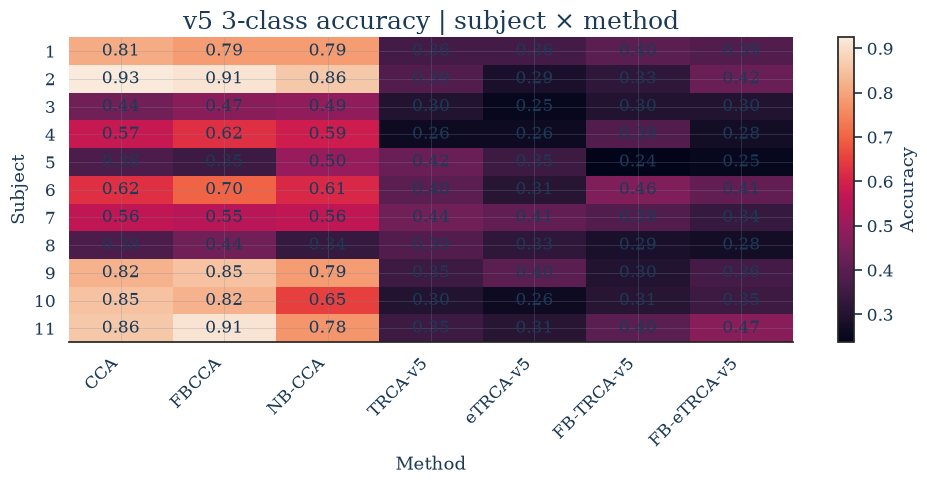

In [88]:
# Heatmap: subject x method accuracy.
fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(subject_method_table_v5.to_numpy(), aspect="auto")
ax.set_xticks(np.arange(subject_method_table_v5.shape[1]))
ax.set_xticklabels(subject_method_table_v5.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(subject_method_table_v5.shape[0]))
ax.set_yticklabels(subject_method_table_v5.index)
ax.set_xlabel("Method")
ax.set_ylabel("Subject")
ax.set_title("v5 3-class accuracy | subject × method")
fig.colorbar(image, ax=ax, label="Accuracy")

for i in range(subject_method_table_v5.shape[0]):
    for j in range(subject_method_table_v5.shape[1]):
        value = subject_method_table_v5.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()


## 21.4 SNR heatmap: subject × stimulation frequency

For each trial, the SNR value used here is the local SNR evaluated at the **true stimulation frequency**. The heatmap reports the median trial-level SNR in dB for each subject × frequency cell.

This separates two hypotheses:

- a generally weak/noisy participant,
- a participant who responds poorly only to a particular stimulation frequency.

The v5 heatmap is recomputed from the posterior channels returned by MOABB, without the additional v4 broad Chebyshev pass, so the preprocessing choice is explicit.


In [89]:
snr_df_5_v5 = build_snr_dataframe(
    trials=X_v5_5_post,
    true_labels=y_v5_5,
    target_freqs=V5_TARGET_FREQS_5,
    fs=FS,
    metadata=meta_v5_5,
)


def v5_true_target_snr_db(row: pd.Series) -> float:
    return float(row[f"SNRdB_{float(row['true_label']):.2f}"])

snr_df_5_v5["true_target_snr_db"] = snr_df_5_v5.apply(v5_true_target_snr_db, axis=1)

snr_subject_frequency_v5 = snr_df_5_v5.pivot_table(
    index="subject",
    columns="true_label",
    values="true_target_snr_db",
    aggfunc="median",
).sort_index()

snr_subject_frequency_v5


true_label,6.66,7.50,8.57,10.00,12.00
subject,,,,,
1,-0.753814,2.069072,3.319254,7.838406,5.661282
2,-1.517957,0.000698,2.127169,4.090485,3.044230
3,-1.923849,-0.667802,-0.315749,-0.334204,-0.774236
4,1.896082,-1.476213,1.403341,0.176757,2.099401
5,-5.095456,-0.620281,-1.953809,0.538421,-4.170996
6,-1.825139,-2.360652,0.644755,0.451972,5.139416
7,-2.107825,-0.390377,-0.853397,2.117058,-0.847630
8,-1.761326,-1.022911,-0.059291,0.097096,0.462131
9,-0.842558,2.782901,4.121215,3.613765,3.326954


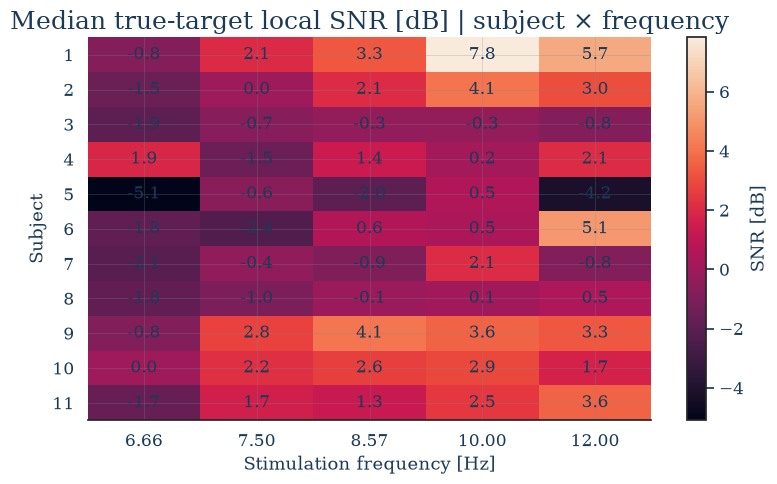

In [90]:
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(snr_subject_frequency_v5.to_numpy(), aspect="auto")
ax.set_xticks(np.arange(snr_subject_frequency_v5.shape[1]))
ax.set_xticklabels([f"{float(f):.2f}" for f in snr_subject_frequency_v5.columns])
ax.set_yticks(np.arange(snr_subject_frequency_v5.shape[0]))
ax.set_yticklabels(snr_subject_frequency_v5.index)
ax.set_xlabel("Stimulation frequency [Hz]")
ax.set_ylabel("Subject")
ax.set_title("Median true-target local SNR [dB] | subject × frequency")
fig.colorbar(image, ax=ax, label="SNR [dB]")

for i in range(snr_subject_frequency_v5.shape[0]):
    for j in range(snr_subject_frequency_v5.shape[1]):
        value = snr_subject_frequency_v5.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()


## 21.5 Fundamental and harmonic analysis

For the selected 3-class design, the first three frequency components are:

- 8.57, 17.14, 25.71 Hz,
- 10, 20, 30 Hz,
- 12, 24, 36 Hz.

All are below the 45 Hz upper bound used in the notebook-level analyses. This section computes local SNR for each component and additionally compares SNR at a target component on trials of the corresponding class versus all non-target trials.

### PSD estimator note

The existing notebook often calls `welch(..., nperseg=trial_length)`. With a ~3 s trial this produces effectively a single long segment, so it behaves closer to a windowed periodogram than to the classical multi-segment Welch estimator. That choice is retained here for **frequency resolution** and is described explicitly rather than attributing variance reduction to segment averaging.


In [91]:
def v5_harmonic_snr_scan(
    trials: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame,
    target_freqs: list[float],
    fs: int,
    harmonics: tuple[int, ...] = (1, 2, 3),
    max_freq: float = 45.0,
) -> pd.DataFrame:
    """Computes SNR at every target-frequency harmonic on every trial once PSD is available."""
    rows = []
    labels = np.asarray(labels, dtype=float)
    metadata = metadata.reset_index(drop=True)

    for trial_idx, trial in enumerate(trials):
        freqs, psd = compute_trial_mean_psd(
            trial=trial,
            fs=fs,
            nperseg=trial.shape[1],  # full-window / periodogram-like for resolution
        )

        for target_freq in target_freqs:
            for h in harmonics:
                component_freq = float(target_freq) * h
                if component_freq > min(max_freq, fs / 2):
                    continue

                _, snr_db = compute_snr_at_freq(
                    freqs=freqs,
                    psd=psd,
                    target_freq=component_freq,
                    noise_width=2,
                    skip_width=1,
                )

                rows.append({
                    "trial": trial_idx,
                    "subject": metadata.iloc[trial_idx]["subject"],
                    "true_label": float(labels[trial_idx]),
                    "target_freq": float(target_freq),
                    "harmonic": int(h),
                    "component_freq": component_freq,
                    "is_target_trial": bool(np.isclose(labels[trial_idx], target_freq, atol=0.01)),
                    "snr_db": snr_db,
                })

    return pd.DataFrame(rows)


harmonic_snr_v5 = v5_harmonic_snr_scan(
    X_v5_3_post,
    y_v5_3,
    meta_v5_3,
    V5_TARGET_FREQS_3,
    FS,
)

harmonic_target_summary_v5 = (
    harmonic_snr_v5[harmonic_snr_v5["is_target_trial"]]
    .groupby(["target_freq", "harmonic", "component_freq"])["snr_db"]
    .median()
    .rename("median_target_snr_db")
    .reset_index()
)

harmonic_target_summary_v5


,target_freq,harmonic,component_freq,median_target_snr_db
0,8.57,1,8.57,1.268096
1,8.57,2,17.14,0.561369
2,8.57,3,25.71,0.161217
3,10.00,1,10.00,2.179701
4,10.00,2,20.00,1.727615
5,10.00,3,30.00,0.854579
6,12.00,1,12.00,1.729672
7,12.00,2,24.00,1.773961
8,12.00,3,36.00,0.499556


In [92]:
target_snr = (
    harmonic_snr_v5[harmonic_snr_v5["is_target_trial"]]
    .groupby(["target_freq", "harmonic", "component_freq"])["snr_db"]
    .median()
    .rename("target_median_snr_db")
)

nontarget_snr = (
    harmonic_snr_v5[~harmonic_snr_v5["is_target_trial"]]
    .groupby(["target_freq", "harmonic", "component_freq"])["snr_db"]
    .median()
    .rename("nontarget_median_snr_db")
)

harmonic_contrast_v5 = pd.concat([target_snr, nontarget_snr], axis=1).reset_index()
harmonic_contrast_v5["target_minus_nontarget_db"] = (
    harmonic_contrast_v5["target_median_snr_db"]
    - harmonic_contrast_v5["nontarget_median_snr_db"]
)

harmonic_contrast_v5


,target_freq,harmonic,component_freq,target_median_snr_db,nontarget_median_snr_db,target_minus_nontarget_db
0,8.57,1,8.57,1.268096,-0.737987,2.006083
1,8.57,2,17.14,0.561369,-0.723631,1.285000
2,8.57,3,25.71,0.161217,-1.077485,1.238703
3,10.00,1,10.00,2.179701,-0.492914,2.672615
4,10.00,2,20.00,1.727615,-0.319260,2.046875
5,10.00,3,30.00,0.854579,-0.658206,1.512785
6,12.00,1,12.00,1.729672,-0.702963,2.432635
7,12.00,2,24.00,1.773961,-0.640801,2.414762
8,12.00,3,36.00,0.499556,-0.509317,1.008873


## 21.6 Predefined channel-set analysis

Only three pre-specified montages are compared:

1. `O1 + O2`,
2. `O1 + O2 + P7 + P8`,
3. all 14 available channels.

This is intentionally **not** an exhaustive channel search. The purpose is to test a small physiological hypothesis: CCA/FBCCA may already work well on posterior channels, whereas TRCA/eTRCA spatial filters may benefit more from a broader montage.

Because the three sets are defined before looking at the v5 results, the study is less prone to channel-selection overfitting than brute-force subset search. It is still exploratory because the same dataset is used to compare configurations.


In [93]:
def v5_result_metrics_row(
    df: pd.DataFrame,
    method: str,
    n_classes: int,
    **extra,
) -> dict:
    subject_acc = v5_subject_accuracy_series(df) if "subject" in df.columns else pd.Series(dtype=float)
    lo, hi = v5_bootstrap_mean_ci(subject_acc) if len(subject_acc) else (np.nan, np.nan)
    row = {
        "method": method,
        "n_classes": n_classes,
        "chance_level": 1 / n_classes,
        "pooled_accuracy": safe_accuracy(df),
        "balanced_accuracy": safe_balanced_accuracy(df),
        "mean_subject_accuracy": subject_acc.mean() if len(subject_acc) else np.nan,
        "median_subject_accuracy": subject_acc.median() if len(subject_acc) else np.nan,
        "std_subject_accuracy": subject_acc.std(ddof=1) if len(subject_acc) > 1 else np.nan,
        "ci95_low": lo,
        "ci95_high": hi,
    }
    row["gain_over_chance"] = row["pooled_accuracy"] - row["chance_level"]
    row.update(extra)
    return row


channel_study_rows_v5 = []
channel_study_dfs_v5 = {}

if V5_RUN_CHANNEL_STUDY:
    for channel_set_name, channel_indices in V5_CHANNEL_SETS.items():
        Xc = v5_prepare_trials(X_v5_3_all, FS, channel_indices=channel_indices)

        cca_df = cca_predict(
            Xc, y_v5_3, V5_TARGET_FREQS_3, FS,
            filter_band=None, n_harmonics=3, metadata=meta_v5_3,
        )
        fbcca_df = fbcca_predict(
            Xc, y_v5_3, V5_TARGET_FREQS_3, FS,
            filter_bands=V5_FBANDS_CURRENT, n_harmonics=3, metadata=meta_v5_3,
        )
        trca_df = v5_subject_dependent_cv(
            v5_trca_train_test_predict, Xc, y_v5_3,
            V5_TARGET_FREQS_3, FS, meta_v5_3,
        )
        etrca_df = v5_subject_dependent_cv(
            v5_etrca_train_test_predict, Xc, y_v5_3,
            V5_TARGET_FREQS_3, FS, meta_v5_3,
        )

        for method_name, df in {
            "CCA": cca_df,
            "FBCCA": fbcca_df,
            "TRCA-v5": trca_df,
            "eTRCA-v5": etrca_df,
        }.items():
            channel_study_dfs_v5[(channel_set_name, method_name)] = df
            channel_study_rows_v5.append(v5_result_metrics_row(
                df,
                method=method_name,
                n_classes=3,
                channel_set=channel_set_name,
                n_channels=len(channel_indices),
            ))

channel_study_v5 = pd.DataFrame(channel_study_rows_v5)
channel_study_v5.sort_values(["method", "pooled_accuracy"], ascending=[True, False]) if len(channel_study_v5) else channel_study_v5


,method,n_classes,chance_level,pooled_accuracy,balanced_accuracy,mean_subject_accuracy,median_subject_accuracy,std_subject_accuracy,ci95_low,ci95_high,gain_over_chance,channel_set,n_channels
4,CCA,3,0.333333,0.656818,0.662626,0.656818,0.6250,0.206788,0.536364,0.767045,0.323485,posterior_4,4
0,CCA,3,0.333333,0.644318,0.648687,0.644318,0.6375,0.221526,0.518182,0.765909,0.310985,O1_O2,2
8,CCA,3,0.333333,0.611364,0.618384,0.611364,0.6000,0.162351,0.520455,0.701165,0.278030,all_14,14
5,FBCCA,3,0.333333,0.675000,0.682424,0.675000,0.7000,0.199844,0.555682,0.780682,0.341667,posterior_4,4
1,FBCCA,3,0.333333,0.661364,0.667879,0.661364,0.6750,0.209498,0.538636,0.775000,0.328030,O1_O2,2
9,FBCCA,3,0.333333,0.631818,0.641616,0.631818,0.7625,0.184676,0.527244,0.730682,0.298485,all_14,14
2,TRCA-v5,3,0.333333,0.364773,0.367071,0.364773,0.3375,0.056684,0.334091,0.397727,0.031439,O1_O2,2
6,TRCA-v5,3,0.333333,0.360227,0.361010,0.360227,0.3625,0.055005,0.327273,0.390909,0.026894,posterior_4,4
10,TRCA-v5,3,0.333333,0.359091,0.357374,0.359091,0.3500,0.084611,0.311364,0.405682,0.025758,all_14,14
3,eTRCA-v5,3,0.333333,0.382955,0.384646,0.382955,0.3750,0.077917,0.342045,0.429545,0.049621,O1_O2,2


## 21.7 Trial-onset trimming study

The hypothesis is that the earliest part of a stimulus epoch may contain transient visual activity or a less stable steady-state response. The v5 grid is deliberately small: `0.00`, `0.25`, and `0.50 s`.

This remains an **exploratory hyperparameter study**. The best trim value must not be presented as if it were chosen on independent test data. Removing more time also shortens an already ~3 s epoch, so 0.75 s is not part of the default v5 grid.


In [94]:
trim_study_rows_v5 = []
trim_study_dfs_v5 = {}

if V5_RUN_TRIM_STUDY:
    Xbase = v5_prepare_trials(
        X_v5_3_all,
        FS,
        channel_indices=V5_CHANNEL_SETS["posterior_4"],
    )

    for trim_sec in V5_TRIM_OPTIONS_SEC:
        Xt = trim_trials(Xbase, FS, trim_start_sec=trim_sec)

        cca_df = cca_predict(
            Xt, y_v5_3, V5_TARGET_FREQS_3, FS,
            filter_band=None, n_harmonics=3, metadata=meta_v5_3,
        )
        fbcca_df = fbcca_predict(
            Xt, y_v5_3, V5_TARGET_FREQS_3, FS,
            filter_bands=V5_FBANDS_CURRENT, n_harmonics=3, metadata=meta_v5_3,
        )
        trca_df = v5_subject_dependent_cv(
            v5_trca_train_test_predict, Xt, y_v5_3,
            V5_TARGET_FREQS_3, FS, meta_v5_3,
        )
        etrca_df = v5_subject_dependent_cv(
            v5_etrca_train_test_predict, Xt, y_v5_3,
            V5_TARGET_FREQS_3, FS, meta_v5_3,
        )

        for method_name, df in {
            "CCA": cca_df,
            "FBCCA": fbcca_df,
            "TRCA-v5": trca_df,
            "eTRCA-v5": etrca_df,
        }.items():
            trim_study_dfs_v5[(trim_sec, method_name)] = df
            trim_study_rows_v5.append(v5_result_metrics_row(
                df,
                method=method_name,
                n_classes=3,
                trim_start_sec=trim_sec,
                remaining_duration_sec=Xt.shape[2] / FS,
            ))

trim_study_v5 = pd.DataFrame(trim_study_rows_v5)
trim_study_v5.sort_values(["method", "pooled_accuracy"], ascending=[True, False]) if len(trim_study_v5) else trim_study_v5


,method,n_classes,chance_level,pooled_accuracy,balanced_accuracy,mean_subject_accuracy,median_subject_accuracy,std_subject_accuracy,ci95_low,ci95_high,gain_over_chance,trim_start_sec,remaining_duration_sec
4,CCA,3,0.333333,0.690909,0.695354,0.690909,0.6125,0.199381,0.577273,0.800000,0.357576,0.25,2.757812
8,CCA,3,0.333333,0.663636,0.668283,0.663636,0.5750,0.214145,0.543182,0.780710,0.330303,0.50,2.507812
0,CCA,3,0.333333,0.656818,0.662626,0.656818,0.6250,0.206788,0.536364,0.767045,0.323485,0.00,3.007812
5,FBCCA,3,0.333333,0.694318,0.701010,0.694318,0.7250,0.201352,0.576108,0.801165,0.360985,0.25,2.757812
9,FBCCA,3,0.333333,0.688636,0.695556,0.688636,0.6625,0.196250,0.576108,0.794318,0.355303,0.50,2.507812
1,FBCCA,3,0.333333,0.675000,0.682424,0.675000,0.7000,0.199844,0.555682,0.780682,0.341667,0.00,3.007812
6,TRCA-v5,3,0.333333,0.362500,0.364040,0.362500,0.3750,0.052440,0.331818,0.390909,0.029167,0.25,2.757812
2,TRCA-v5,3,0.333333,0.360227,0.361010,0.360227,0.3625,0.055005,0.327273,0.390909,0.026894,0.00,3.007812
10,TRCA-v5,3,0.333333,0.353409,0.354343,0.353409,0.3625,0.082176,0.305682,0.400000,0.020076,0.50,2.507812
11,eTRCA-v5,3,0.333333,0.342045,0.343636,0.342045,0.3500,0.062568,0.307955,0.377273,0.008712,0.50,2.507812


## 21.8 Small FBCCA hyperparameter study

The existing FBCCA implementation already uses the standard structure:

\[
\text{score}_f = \sum_m w_m \rho_{f,m}^2,
\qquad w_m=m^{-a}+b.
\]

Therefore, `rho²` is **kept** for FBCCA. The v5 study does not brute-force arbitrary parameters. It compares a few interpretable alternatives around the current `a=1.25, b=0.25` choice and one literature-inspired lower-cutoff progression adapted to the source sampling/bandwidth.

Because the same dataset is used to compare these configurations, this table is an optimization/design study, not an unbiased final test.


In [95]:
def v5_fb_weights(n_bands: int, a: float = 1.25, b: float = 0.25) -> np.ndarray:
    return np.array([(m + 1) ** (-a) + b for m in range(n_bands)], dtype=float)


V5_FBCCA_CONFIGS = [
    {"name": "current_h2", "bands": V5_FBANDS_CURRENT, "n_harmonics": 2, "a": 1.25, "b": 0.25},
    {"name": "current_h3", "bands": V5_FBANDS_CURRENT, "n_harmonics": 3, "a": 1.25, "b": 0.25},
    {"name": "a1.00_b0.25", "bands": V5_FBANDS_CURRENT, "n_harmonics": 3, "a": 1.00, "b": 0.25},
    {"name": "a1.50_b0.25", "bands": V5_FBANDS_CURRENT, "n_harmonics": 3, "a": 1.50, "b": 0.25},
    {"name": "a1.25_b0.00", "bands": V5_FBANDS_CURRENT, "n_harmonics": 3, "a": 1.25, "b": 0.00},
    {"name": "8Hz_adapted_h3", "bands": V5_FBANDS_8HZ_ADAPTED, "n_harmonics": 3, "a": 1.25, "b": 0.25},
]

fbcca_grid_rows_v5 = []
fbcca_grid_dfs_v5 = {}

if V5_RUN_FBCCA_GRID:
    for cfg in V5_FBCCA_CONFIGS:
        weights = v5_fb_weights(len(cfg["bands"]), cfg["a"], cfg["b"])
        df = fbcca_predict(
            trials=X_v5_3_post,
            true_labels=y_v5_3,
            target_freqs=V5_TARGET_FREQS_3,
            fs=FS,
            filter_bands=cfg["bands"],
            n_harmonics=cfg["n_harmonics"],
            metadata=meta_v5_3,
            weights=weights,
        )
        fbcca_grid_dfs_v5[cfg["name"]] = df
        fbcca_grid_rows_v5.append(v5_result_metrics_row(
            df,
            method="FBCCA",
            n_classes=3,
            config=cfg["name"],
            n_harmonics=cfg["n_harmonics"],
            a=cfg["a"],
            b=cfg["b"],
            filter_bands=str(cfg["bands"]),
        ))

fbcca_grid_v5 = pd.DataFrame(fbcca_grid_rows_v5)
fbcca_grid_v5.sort_values("pooled_accuracy", ascending=False) if len(fbcca_grid_v5) else fbcca_grid_v5


,method,n_classes,chance_level,pooled_accuracy,balanced_accuracy,mean_subject_accuracy,median_subject_accuracy,std_subject_accuracy,ci95_low,ci95_high,gain_over_chance,config,n_harmonics,a,b,filter_bands
5,FBCCA,3,0.333333,0.696591,0.701212,0.696591,0.7375,0.189991,0.582955,0.796591,0.363258,8Hz_adapted_h3,3,1.25,0.25,"[(5, 45), (14, 45), (22, 45)]"
3,FBCCA,3,0.333333,0.678409,0.685657,0.678409,0.6875,0.194703,0.562500,0.781818,0.345076,a1.50_b0.25,3,1.50,0.25,"[(5, 45), (10, 45), (15, 45)]"
2,FBCCA,3,0.333333,0.676136,0.683232,0.676136,0.7125,0.202905,0.555653,0.784091,0.342803,a1.00_b0.25,3,1.00,0.25,"[(5, 45), (10, 45), (15, 45)]"
0,FBCCA,3,0.333333,0.676136,0.683838,0.676136,0.7000,0.202288,0.556818,0.784091,0.342803,current_h2,2,1.25,0.25,"[(5, 45), (10, 45), (15, 45)]"
4,FBCCA,3,0.333333,0.676136,0.683636,0.676136,0.7125,0.191332,0.562472,0.777273,0.342803,a1.25_b0.00,3,1.25,0.00,"[(5, 45), (10, 45), (15, 45)]"
1,FBCCA,3,0.333333,0.675000,0.682424,0.675000,0.7000,0.199844,0.555682,0.780682,0.341667,current_h3,3,1.25,0.25,"[(5, 45), (10, 45), (15, 45)]"


## 21.9 Non-destructive trial-quality analysis

This section does **not** remove trials. It computes simple QC features independent of classifier correctness:

- maximum channel peak-to-peak amplitude,
- median channel variance,
- median channel MAD,
- median absolute kurtosis.

Robust z-scores are calculated across trials and a conservative flag is shown only as a diagnostic. No threshold is tuned to maximize classification accuracy, and the number/fraction of flagged trials is reported explicitly.


In [96]:
from scipy.stats import kurtosis


def v5_mad(x: np.ndarray, axis=None) -> np.ndarray:
    med = np.median(x, axis=axis, keepdims=True)
    return np.median(np.abs(x - med), axis=axis)


def v5_trial_qc_table(
    trials: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame,
) -> pd.DataFrame:
    rows = []
    for i, trial in enumerate(np.asarray(trials, dtype=float)):
        channel_ptp = np.ptp(trial, axis=1)
        channel_var = np.var(trial, axis=1)
        channel_mad = v5_mad(trial, axis=1)
        channel_kurt = kurtosis(trial, axis=1, fisher=True, bias=False, nan_policy="omit")

        rows.append({
            "trial": i,
            "subject": metadata.iloc[i]["subject"],
            "true_label": float(labels[i]),
            "peak_to_peak_max": float(np.nanmax(channel_ptp)),
            "variance_median": float(np.nanmedian(channel_var)),
            "mad_median": float(np.nanmedian(channel_mad)),
            "abs_kurtosis_median": float(np.nanmedian(np.abs(channel_kurt))),
        })

    qc = pd.DataFrame(rows)
    metric_cols = [
        "peak_to_peak_max", "variance_median", "mad_median", "abs_kurtosis_median"
    ]

    for col in metric_cols:
        med = qc[col].median()
        mad = np.median(np.abs(qc[col] - med))
        scale = 1.4826 * mad
        if scale <= 0 or not np.isfinite(scale):
            qc[f"rz_{col}"] = 0.0
        else:
            qc[f"rz_{col}"] = (qc[col] - med) / scale

    rz_cols = [f"rz_{col}" for col in metric_cols]
    qc["qc_flag"] = qc[rz_cols].abs().max(axis=1) > V5_QC_ROBUST_Z_THRESHOLD
    return qc


qc_trials_v5 = v5_trial_qc_table(X_v5_5_post, y_v5_5, meta_v5_5)
print(f"QC flagged trials: {qc_trials_v5['qc_flag'].sum()} / {len(qc_trials_v5)} "
      f"({qc_trials_v5['qc_flag'].mean():.2%})")

qc_subject_summary_v5 = qc_trials_v5.groupby("subject").agg(
    peak_to_peak_median=("peak_to_peak_max", "median"),
    variance_median=("variance_median", "median"),
    mad_median=("mad_median", "median"),
    abs_kurtosis_median=("abs_kurtosis_median", "median"),
    qc_flag_fraction=("qc_flag", "mean"),
)
qc_subject_summary_v5


QC flagged trials: 213 / 1375 (15.49%)


,peak_to_peak_median,variance_median,mad_median,abs_kurtosis_median,qc_flag_fraction
subject,,,,,
1,75.412369,82.058651,6.016012,0.238267,0.072
2,33.659394,22.781218,2.950480,0.376577,0.024
3,109.506639,72.586262,4.899795,0.823714,0.360
4,49.445554,42.781241,4.238953,0.273211,0.048
5,614.212937,125.218916,6.788968,0.289009,0.872
6,59.796200,44.074122,4.344257,0.282942,0.000
7,45.941556,36.627181,3.883925,0.287085,0.088
8,72.544773,40.924164,3.989976,0.361402,0.056
9,31.231445,19.045909,2.666086,0.445842,0.152


## 21.10 Fair comparison by class count

A 3-class, 4-class and 5-class classifier solve different tasks and have different chance levels. v5 therefore produces **three separate benchmark tables**.

Frequency-set reduction remains a separate design study. A higher raw accuracy after removing classes is not interpreted as a pure model improvement.

For every table, `gain_over_chance = pooled_accuracy - chance_level` is included only as a descriptive aid; it does not replace accuracy, balanced accuracy or subject-level statistics.


In [97]:
# Recompute the calibration-free baselines under one explicit v5 convention:
# posterior-4, no extra broad filter for SNR/CCA, filter bank only where required.

def v5_calibration_free_set(
    X_post: np.ndarray,
    y: np.ndarray,
    meta: pd.DataFrame,
    target_freqs: list[float],
) -> dict[str, pd.DataFrame]:
    snr_df = build_snr_dataframe(
        X_post, y, target_freqs, FS, metadata=meta,
    )
    cca_df = cca_predict(
        X_post, y, target_freqs, FS,
        filter_band=None, n_harmonics=3, metadata=meta,
    )
    fbcca_df = fbcca_predict(
        X_post, y, target_freqs, FS,
        filter_bands=V5_FBANDS_CURRENT, n_harmonics=3, metadata=meta,
    )
    return {"SNR": snr_df, "CCA": cca_df, "FBCCA": fbcca_df}


v5_methods_5 = v5_calibration_free_set(X_v5_5_post, y_v5_5, meta_v5_5, V5_TARGET_FREQS_5)
v5_methods_4 = v5_calibration_free_set(X_v5_4_post, y_v5_4, meta_v5_4, V5_TARGET_FREQS_4)
v5_methods_3 = v5_calibration_free_set(X_v5_3_post, y_v5_3, meta_v5_3, V5_TARGET_FREQS_3)

# Add the corrected calibrated methods only to the matching 3-class problem.
v5_methods_3.update({
    "NB-CCA": nbcca_df_advanced,
    "TRCA-v5": trca_df_v5,
    "eTRCA-v5": etrca_df_v5,
    "FB-TRCA-v5": fbtrca_df_v5,
    "FB-eTRCA-v5": fbetrca_df_v5,
})


def v5_benchmark_table(method_dfs: dict[str, pd.DataFrame], n_classes: int) -> pd.DataFrame:
    rows = [
        v5_result_metrics_row(df, method=name, n_classes=n_classes)
        for name, df in method_dfs.items()
    ]
    return pd.DataFrame(rows).sort_values("pooled_accuracy", ascending=False).reset_index(drop=True)


benchmark_5class_v5 = v5_benchmark_table(v5_methods_5, 5)
benchmark_4class_v5 = v5_benchmark_table(v5_methods_4, 4)
benchmark_3class_v5 = v5_benchmark_table(v5_methods_3, 3)

print("5-class benchmark")
display(benchmark_5class_v5)
print("4-class benchmark")
display(benchmark_4class_v5)
print("3-class benchmark")
display(benchmark_3class_v5)


5-class benchmark


,method,n_classes,chance_level,pooled_accuracy,balanced_accuracy,mean_subject_accuracy,median_subject_accuracy,std_subject_accuracy,ci95_low,ci95_high,gain_over_chance
0,FBCCA,5,0.2,0.556364,0.551091,0.556364,0.528,0.245728,0.413091,0.688727,0.356364
1,CCA,5,0.2,0.549091,0.542788,0.549091,0.488,0.246324,0.408000,0.682182,0.349091
2,SNR,5,0.2,0.333818,0.324970,0.333818,0.360,0.116102,0.269818,0.400727,0.133818


4-class benchmark


,method,n_classes,chance_level,pooled_accuracy,balanced_accuracy,mean_subject_accuracy,median_subject_accuracy,std_subject_accuracy,ci95_low,ci95_high,gain_over_chance
0,FBCCA,4,0.25,0.614719,0.617576,0.614719,0.638095,0.228069,0.480519,0.736797,0.364719
1,CCA,4,0.25,0.601732,0.603788,0.601732,0.600000,0.228881,0.470130,0.724697,0.351732
2,SNR,4,0.25,0.412987,0.412727,0.412987,0.409524,0.125431,0.344589,0.486580,0.162987


3-class benchmark


,method,n_classes,chance_level,pooled_accuracy,balanced_accuracy,mean_subject_accuracy,median_subject_accuracy,std_subject_accuracy,ci95_low,ci95_high,gain_over_chance
0,FBCCA,3,0.333333,0.675000,0.682424,0.675000,0.7000,0.199844,0.555682,0.780682,0.341667
1,CCA,3,0.333333,0.656818,0.662626,0.656818,0.6250,0.206788,0.536364,0.767045,0.323485
2,NB-CCA,3,0.333333,0.631818,0.634545,0.631818,0.6125,0.159527,0.537500,0.718210,0.298485
3,SNR,3,0.333333,0.511364,0.513939,0.511364,0.5125,0.123801,0.443182,0.582955,0.178030
4,TRCA-v5,3,0.333333,0.360227,0.361010,0.360227,0.3625,0.055005,0.327273,0.390909,0.026894
5,FB-eTRCA-v5,3,0.333333,0.350000,0.351111,0.350000,0.3500,0.071151,0.309091,0.390909,0.016667
6,FB-TRCA-v5,3,0.333333,0.345455,0.347677,0.345455,0.3250,0.066208,0.310227,0.382983,0.012121
7,eTRCA-v5,3,0.333333,0.321591,0.321616,0.321591,0.3125,0.055083,0.290909,0.353409,-0.011742


## 21.11 Interpretation rules for the final v5 conclusions

After executing Section 21, update the scientific interpretation using the following rules:

1. **Do not rank different class-count problems in one leaderboard.** Compare methods within 3, 4 or 5 classes separately.
2. **Call 8.57 / 10 / 12 Hz an exploratory selected subset.** A suitable formulation is: *“Within the analyzed dataset and current pipeline, 8.57, 10.00 and 12.00 Hz formed the most separable investigated subset.”*
3. **Do not claim that alpha activity masks SSVEP unless the analysis directly demonstrates that mechanism.** Prefer descriptive spectral statements.
4. **Report responder variability.** If mean and median subject accuracy differ materially, or the heatmap contains very weak subjects, state this explicitly.
5. **Treat channel, trim and FBCCA grids as exploratory optimization.** If one setting is selected after inspecting these tables, its pooled accuracy is not an independent final test score.
6. **TRCA-family interpretation depends on the corrected v5 run.** Compare v5 TRCA/eTRCA with the preserved v4 outputs to determine whether scoring implementation, preprocessing, or data reproducibility was the dominant issue.
7. **Artifact QC is diagnostic.** Do not remove flagged trials unless a rejection rule is pre-defined independently of classification performance and the retained/removed trial counts are reported.

### If a publication-grade unbiased estimate becomes necessary

The next methodological step would be nested subject-dependent CV: choose trim/channel/filter-bank parameters only in inner folds and report performance in untouched outer folds. That is intentionally not forced into this EDA unless the project moves from exploratory engineering analysis to a formal benchmark/paper.


In [98]:
# Compact final v5 report object. This avoids manually copying numbers into Markdown.
v5_report = {
    "benchmark_5class": benchmark_5class_v5,
    "benchmark_4class": benchmark_4class_v5,
    "benchmark_3class": benchmark_3class_v5,
    "subject_method_accuracy": subject_method_table_v5,
    "subject_method_summary": subject_method_summary_v5,
    "snr_subject_frequency": snr_subject_frequency_v5,
    "harmonic_contrast": harmonic_contrast_v5,
    "channel_study": channel_study_v5,
    "trim_study": trim_study_v5,
    "fbcca_grid": fbcca_grid_v5,
    "qc_subject_summary": qc_subject_summary_v5,
}

print("v5 report sections:", list(v5_report))


v5 report sections: ['benchmark_5class', 'benchmark_4class', 'benchmark_3class', 'subject_method_accuracy', 'subject_method_summary', 'snr_subject_frequency', 'harmonic_contrast', 'channel_study', 'trim_study', 'fbcca_grid', 'qc_subject_summary']


# References and useful links

## Dataset and tooling

1. MOABB MAMEM3 documentation:  
   https://moabb.neurotechx.com/docs/generated/moabb.datasets.MAMEM3.html

2. MOABB within-session SSVEP example:  
   https://moabb.neurotechx.com/docs/auto_examples/paradigm_examples/plot_within_session_ssvep.html

3. MOABB cross-subject SSVEP example with CCA/TRCA/MsetCCA:  
   https://moabb.neurotechx.com/docs/auto_examples/paradigm_examples/plot_cross_subject_ssvep.html

4. SSVEP Analysis Toolbox documentation:  
   https://ssvep-analysis-toolbox.readthedocs.io/en/stable/

## CCA and CCA-based SSVEP methods

5. Lin et al. Frequency recognition based on canonical correlation analysis for SSVEP-based BCIs:  
   https://pubmed.ncbi.nlm.nih.gov/17549911/

6. CCA-based SSVEP methods comparison study, including standard CCA, IT-CCA, MsetCCA and combined CCA approaches:  
   https://pmc.ncbi.nlm.nih.gov/articles/PMC4610694/

## FBCCA

7. Chen et al. Filter bank canonical correlation analysis for implementing a high-speed SSVEP-based BCI:  
   https://pubmed.ncbi.nlm.nih.gov/26035476/

## MsetCCA

8. Zhang et al. Frequency recognition in SSVEP-based BCI using multiset canonical correlation analysis:  
   https://pubmed.ncbi.nlm.nih.gov/24694168/

## TRCA and eTRCA

9. Nakanishi et al. Enhancing detection of SSVEPs using TRCA:  
   https://pubmed.ncbi.nlm.nih.gov/28436836/

10. Full open-access TRCA article:  
   https://pmc.ncbi.nlm.nih.gov/articles/PMC5783827/

## Narrow-band and newer extensions

11. Narrow band-pass filtered CCA for SSVEP frequency identification:  
   https://pubmed.ncbi.nlm.nih.gov/38861953/

12. Filter bank temporally delayed CCA for short-window SSVEP classification:  
   https://pmc.ncbi.nlm.nih.gov/articles/PMC7501359/


## v5 validation references

13. Nakanishi et al. original TRCA/eTRCA formulation (open access):  
    https://pmc.ncbi.nlm.nih.gov/articles/PMC5783827/

14. MOABB MAMEM3 current dataset metadata / preprocessing summary:  
    https://moabb.neurotechx.com/docs/generated/moabb.datasets.MAMEM3.html

15. MOABB preprocessing pipeline overview:  
    https://moabb.neurotechx.com/docs/auto_examples/advanced_examples/plot_pre_processing_steps.html
